# 4. Linear Neural Networks for Classification

Now that you have worked through all of the mechanics you are ready to apply the skills you have learned to broader kinds of tasks. Even as we pivot towards classification, most of the plumbing remains the same: loading the data, passing it through the model, generating output, calculating the loss, taking gradients with respect to weights, and updating the model. However, the precise form of the targets, the parametrization of the output layer, and the choice of loss function will adapt to suit the *classification* setting.

## 4.1. Softmax Regression

Regression is the hammer we reach for when we want to answer *how much?* or *how many?* questions. If you want to predict the number of dollars (price) at which a house will be sold, or the number of wins a baseball team might have, or the number of days that a patient will remain hospitalized before being discharged, then you are probably looking for a regression model. However, even within regression models, there are important distinctions. For instance, the price of a house will never be negative and changes might often be *relative* to its baseline price. As such, it might be more effective to regress on the logarithm of the price. Likewise, the number of days a patient spends in hospital is a *discrete nonnegative* random variable. As such, least mean squares might not be an ideal approach either. This sort of time-to-event modeling comes with a host of other complications that are dealt with in a specialized subfield called *survival modeling*.

The point here is not to overwhelm you but just to let you know that there is a lot more to estimation than simply minimizing squared errors. And more broadly, there is a lot more to supervised learning than regression. In this section, we focus on *classification* problems where we put aside *how much?* questions and instead focus on *which category?* questions.

* Does this email belong in the spam folder or the inbox?
* Is this customer more likely to sign up or not to sign up for a subscription service?
* Does this image depict a donkey, a dog, a cat, or a rooster?
* Which movie is Aston most likely to watch next?
* Which section of the book are you going to read next?

Colloquially, machine learning practitioners overload the word *classification* to describe two subtly different problems: (i) those where we are interested only in hard assignments of examples to categories (classes); and (ii) those where we wish to make soft assignments, i.e., to assess the probability that each category applies. The distinction tends to get blurred, in part, because often, even when we only care about hard assignments, we still use models that make soft assignments.

Even more, there are cases where more than one label might be true. For instance, a news article might simultaneously cover the topics of entertainment, business, and space flight, but not the topics of medicine or sports. Thus, categorizing it into one of the above categories on their own would not be very useful. This problem is commonly known as [multi-label classification](https://en.wikipedia.org/wiki/Multi-label_classification). See Tsoumakas and Katakis (2007) for an overview and Huang et al. (2015) for an effective algorithm when tagging images.

### 4.1.1. Classification

To get our feet wet, let's start with a simple image classification problem. Here, each input consists of a $2\times2$ grayscale image. We can represent each pixel value with a single scalar, giving us four features $x_1, x_2, x_3, x_4$. Further, let's assume that each image belongs to one among the categories "cat", "chicken", and "dog".

Next, we have to choose how to represent the labels. We have two obvious choices. Perhaps the most natural impulse would be to choose $y \in \{1, 2, 3\}$, where the integers represent $\{\textrm{dog}, \textrm{cat}, \textrm{chicken}\}$ respectively. This is a great way of *storing* such information on a computer. If the categories had some natural ordering among them, say if we were trying to predict $\{\textrm{baby}, \textrm{toddler}, \textrm{adolescent}, \textrm{young adult}, \textrm{adult}, \textrm{geriatric}\}$, then it might even make sense to cast this as an [ordinal regression](https://en.wikipedia.org/wiki/Ordinal_regression) problem and keep the labels in this format. See Moon et al. (2010) for an overview of different types of ranking loss functions and Beutel et al. (2014) for a Bayesian approach that addresses responses with more than one mode.

In general, classification problems do not come with natural orderings among the classes. Fortunately, statisticians long ago invented a simple way to represent categorical data: the *one-hot encoding*. A one-hot encoding is a vector with as many components as we have categories. The component corresponding to a particular instance's category is set to 1 and all other components are set to 0. In our case, a label $y$ would be a three-dimensional vector, with $(1, 0, 0)$ corresponding to "cat", $(0, 1, 0)$ to "chicken", and $(0, 0, 1)$ to "dog":

$$y \in \{(1, 0, 0), (0, 1, 0), (0, 0, 1)\}. \tag{4.1.1}$$

#### 4.1.1.1. Linear Model

In order to estimate the conditional probabilities associated with all the possible classes, we need a model with multiple outputs, one per class. To address classification with linear models, we will need as many affine functions as we have outputs. Strictly speaking, we only need one fewer, since the final category has to be the difference between $1$ and the sum of the other categories, but for reasons of symmetry we use a slightly redundant parametrization. Each output corresponds to its own affine function. In our case, since we have 4 features and 3 possible output categories, we need 12 scalars to represent the weights ($w$ with subscripts), and 3 scalars to represent the biases ($b$ with subscripts). This yields:

$$ \begin{aligned} o_1 &= x_1 w_{11} + x_2 w_{12} + x_3 w_{13} + x_4 w_{14} + b_1,\\ o_2 &= x_1 w_{21} + x_2 w_{22} + x_3 w_{23} + x_4 w_{24} + b_2,\\ o_3 &= x_1 w_{31} + x_2 w_{32} + x_3 w_{33} + x_4 w_{34} + b_3. \end{aligned} \tag{4.1.2}$$

The corresponding neural network diagram is shown in Fig. 4.1.1. Just as in linear regression, we use a single-layer neural network. And since the calculation of each output, $o_1, o_2$, and $o_3$, depends on every input, $x_1$, $x_2$, $x_3$, and $x_4$, the output layer can also be described as a *fully connected layer*.

<p align="center">
  <img src="http://d2l.ai/_images/softmaxreg.svg"/>
  <br />
  <em>Fig. 4.1.1</em> Softmax regression is a single-layer neural network.
</p>

For a more concise notation we use vectors and matrices: $\mathbf{o} = \mathbf{W} \mathbf{x} + \mathbf{b}$ is much better suited for mathematics and code. Note that we have gathered all of our weights into a $3 \times 4$ matrix and all biases $\mathbf{b} \in \mathbb{R}^3$ in a vector.

---
牧之：为什么要用三个函数呢而不是一个函数呢？一个函数，三个输入得到三个输出，不行吗？

GPT：在分类问题中，使用三个函数（每个类别对应一个函数）而不是一个函数来处理的原因在于，使用多个函数会更好地适应分类问题的特性。这种方法允许模型更加灵活地学习不同类别之间的非线性关系。如果只使用一个函数，尽管可以将多个输入映射到多个输出，但这种方法可能会限制模型的表达能力，难以捕捉不同类别之间的复杂关系。通过使用多个函数（每个类别一个函数），模型可以更好地学习每个类别的特征和判别边界，从而提高分类的准确性。这种方法还更容易扩展到具有更多类别的分类问题。因此，在实践中，为每个类别使用一个函数通常是更可行和有效的方法。

#### 4.1.1.2. The Softmax

Assuming a suitable loss function, we could try, directly, to minimize the difference between $\mathbf{o}$ and the labels $\mathbf{y}$. While it turns out that treating classification as a vector-valued regression problem works surprisingly well, it is nonetheless unsatisfactory in the following ways:

* There is no guarantee that the outputs $o_i$ sum up to $1$ in the way we expect probabilities to behave.
* There is no guarantee that the outputs $o_i$ are even nonnegative, even if their outputs sum up to $1$, or that they do not exceed $1$.

Both aspects render the estimation problem difficult to solve and the solution very brittle to outliers. For instance, if we assume that there is a positive linear dependency between the number of bedrooms and the likelihood that someone will buy a house, the probability might exceed $1$ when it comes to buying a mansion! As such, we need a mechanism to "squish" the outputs.

There are many ways we might accomplish this goal. For instance, we could assume that the outputs $\mathbf{o}$ are corrupted versions of $\mathbf{y}$, where the corruption occurs by means of adding noise $\boldsymbol{\epsilon}$ drawn from a normal distribution. In other words, $\mathbf{y} = \mathbf{o} + \boldsymbol{\epsilon}$, where $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$. This is the so-called [probit model](https://en.wikipedia.org/wiki/Probit_model), first introduced by Fechner (1860). While appealing, it does not work quite as well nor lead to a particularly nice optimization problem, when compared to the softmax.

Another way to accomplish this goal (and to ensure nonnegativity) is to use an exponential function $P(y = i) \propto \exp o_i$. This does indeed satisfy the requirement that the conditional class probability increases with increasing $o_i$, it is monotonic, and all probabilities are nonnegative. We can then transform these values so that they add up to $1$ by dividing each by their sum. This process is called *normalization*. Putting these two pieces together gives us the *softmax* function:

$$\hat{\mathbf{y}} = \mathrm{softmax}(\mathbf{o}) \quad \textrm{where}\quad \hat{y}_i = \frac{\exp(o_i)}{\sum_j \exp(o_j)}. \tag{4.1.3}$$

Note that the largest coordinate of $\mathbf{o}$ corresponds to the most likely class according to $\hat{\mathbf{y}}$. Moreover, because the softmax operation preserves the ordering among its arguments, we do not need to compute the softmax to determine which class has been assigned the highest probability. Thus,

$$ \operatorname*{argmax}_j \hat y_j = \operatorname*{argmax}_j o_j. \tag{4.1.4}$$

The idea of a softmax dates back to Gibbs (1902), who adapted ideas from physics. Dating even further back, Boltzmann, the father of modern statistical physics, used this trick to model a distribution over energy states in gas molecules. In particular, he discovered that the prevalence of a state of energy in a thermodynamic ensemble, such as the molecules in a gas, is proportional to $\exp(-E/kT)$. Here, $E$ is the energy of a state, $T$ is the temperature, and $k$ is the Boltzmann constant. When statisticians talk about increasing or decreasing the "temperature" of a statistical system, they refer to changing $T$ in order to favor lower or higher energy states. Following Gibbs' idea, energy equates to error. Energy-based models (Ranzato et al., 2007) use this point of view when describing problems in deep learning.

---
牧之：为什么说能量等同于误差？

GPT：在深度学习中，能量与误差之间的类比源于能量函数与损失函数之间的相似性。在能量函数中，系统的状态与能量相关联；较低能量对应于更稳定的状态，而较高能量对应于不稳定的状态。类似地，在机器学习中，我们使用损失函数来衡量模型预测与实际目标之间的差异，较低的损失对应于更好的模型性能，而较高的损失对应于较差的模型性能。因此，将能量类比为误差的概念是基于这种相似性：在物理系统中，通过降低能量来获得更稳定的状态；在机器学习中，通过降低损失来改善模型的性能。这个类比的目的是为了以物理学的角度解释和理解机器学习中的优化问题。

#### 4.1.1.3. Vectorization

To improve computational efficiency, we vectorize calculations in minibatches of data. Assume that we are given a minibatch $\mathbf{X} \in \mathbb{R}^{n \times d}$ of $n$ examples with dimensionality (number of inputs) $d$. Moreover, assume that we have $q$ categories in the output. Then the weights satisfy $\mathbf{W} \in \mathbb{R}^{d \times q}$ and the bias satisfies $\mathbf{b} \in \mathbb{R}^{1\times q}$.

$$ \begin{aligned} \mathbf{O} &= \mathbf{X} \mathbf{W} + \mathbf{b}, \\ \hat{\mathbf{Y}} & = \mathrm{softmax}(\mathbf{O}). \end{aligned} \tag{4.1.5}$$

This accelerates the dominant operation into a matrix--matrix product $\mathbf{X} \mathbf{W}$. Moreover, since each row in $\mathbf{X}$ represents a data example, the softmax operation itself can be computed *rowwise*: for each row of $\mathbf{O}$, exponentiate all entries and then normalize them by the sum. Note, though, that care must be taken to avoid exponentiating and taking logarithms of large numbers, since this can cause numerical overflow or underflow. Deep learning frameworks take care of this automatically.

### 4.1.2. Loss Function

Now that we have a mapping from features $\mathbf{x}$ to probabilities $\mathbf{\hat{y}}$, we need a way to optimize the accuracy of this mapping. We will rely on maximum likelihood estimation, the very same method that we encountered when providing a probabilistic justification for the mean squared error loss in Section 3.1.3.

#### 4.1.2.1. Log-Likelihood

The softmax function gives us a vector $\hat{\mathbf{y}}$, which we can interpret as the (estimated) conditional probabilities of each class, given any input $\mathbf{x}$, such as $\hat{y}_1$ = $P(y=\textrm{cat} \mid \mathbf{x})$. In the following we assume that for a dataset with features $\mathbf{X}$ the labels $\mathbf{Y}$ are represented using a one-hot encoding label vector. We can compare the estimates with reality by checking how probable the actual classes are according to our model, given the features:

$$ P(\mathbf{Y} \mid \mathbf{X}) = \prod_{i=1}^n P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}). \tag{4.1.6}$$

We are allowed to use the factorization since we assume that each label is drawn independently from its respective distribution $P(\mathbf{y}\mid\mathbf{x}^{(i)})$. Since maximizing the product of terms is awkward, we take the negative logarithm to obtain the equivalent problem of minimizing the negative log-likelihood:

$$ -\log P(\mathbf{Y} \mid \mathbf{X}) = \sum_{i=1}^n -\log P(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}) = \sum_{i=1}^n l(\mathbf{y}^{(i)}, \hat{\mathbf{y}}^{(i)}), \tag{4.1.7}$$

where for any pair of label $\mathbf{y}$ and model prediction $\hat{\mathbf{y}}$ over $q$ classes, the loss function $l$ is

$$ l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j. \tag{4.1.8}$$

For reasons explained later on, the loss function in (4.1.8) is commonly called the *cross-entropy loss*. Since $\mathbf{y}$ is a one-hot vector of length $q$, the sum over all its coordinates $j$ vanishes for all but one term. Note that the loss $l(\mathbf{y}, \hat{\mathbf{y}})$ is bounded from below by $0$ whenever $\hat{\mathbf{y}}$ is a probability vector: no single entry is larger than $1$, hence their negative logarithm cannot be lower than $0$; $l(\mathbf{y}, \hat{\mathbf{y}}) = 0$ only if we predict the actual label with *certainty*. This can never happen for any finite setting of the weights because taking a softmax output towards $1$ requires taking the corresponding input $o_i$ to infinity (or all other outputs $o_j$ for $j \neq i$ to negative infinity). Even if our model could assign an output probability of $0$, any error made when assigning such high confidence would incur infinite loss ($-\log 0 = \infty$).

#### 4.1.2.2. Softmax and Cross-Entropy Loss

Since the softmax function and the corresponding cross-entropy loss are so common, it is worth understanding a bit better how they are computed. Plugging (4.1.3) into the definition of the loss in (4.1.8) and using the definition of the softmax we obtain

$$
\begin{aligned}
l(\mathbf{y}, \hat{\mathbf{y}}) &=  - \sum_{j=1}^q y_j \log \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} \\
&= \sum_{j=1}^q y_j \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j \\
&= \log \sum_{k=1}^q \exp(o_k) - \sum_{j=1}^q y_j o_j.
\end{aligned} \tag{4.1.9}
$$

To understand a bit better what is going on, consider the derivative with respect to any logit $o_j$. We get

$$
\partial_{o_j} l(\mathbf{y}, \hat{\mathbf{y}}) = \frac{\exp(o_j)}{\sum_{k=1}^q \exp(o_k)} - y_j = \mathrm{softmax}(\mathbf{o})_j - y_j. \tag{4.1.10}
$$

In other words, the derivative is the difference between the probability assigned by our model, as expressed by the softmax operation, and what actually happened, as expressed by elements in the one-hot label vector. In this sense, it is very similar to what we saw in regression, where the gradient was the difference between the observation $y$ and estimate $\hat{y}$. This is not a coincidence. In any exponential family model, the gradients of the log-likelihood are given by precisely this term. This fact makes computing gradients easy in practice.

Now consider the case where we observe not just a single outcome but an entire distribution over outcomes. We can use the same representation as before for the label $\mathbf{y}$. The only difference is that rather than a vector containing only binary entries, say $(0, 0, 1)$, we now have a generic probability vector, say $(0.1, 0.2, 0.7)$. The math that we used previously to define the loss $l$ in (4.1.8) still works well, just that the interpretation is slightly more general. It is the expected value of the loss for a distribution over labels. This loss is called the *cross-entropy loss* and it is one of the most commonly used losses for classification problems. We can demystify the name by introducing just the basics of information theory. In a nutshell, it measures the number of bits needed to encode what we see, $\mathbf{y}$, relative to what we predict that should happen, $\hat{\mathbf{y}}$. We provide a very basic explanation in the following. For further details on information theory see Cover and Thomas (1999) or MacKay (2003).

### 4.1.3. Information Theory Basics

Many deep learning papers use intuition and terms from information theory. To make sense of them, we need some common language. This is a survival guide. *Information theory* deals with the problem of encoding, decoding, transmitting, and manipulating information (also known as data).

#### 4.1.3.1. Entropy

The central idea in information theory is to quantify the amount of information contained in data. This places a  limit on our ability to compress data. For a distribution $P$ its *entropy*, $H[P]$, is defined as:

$$H[P] = \sum_j - P(j) \log P(j). \tag{4.1.11}$$

One of the fundamental theorems of information theory states that in order to encode data drawn randomly from the distribution $P$, we need at least $H[P]$ "nats" to encode it (Shannon, 1948). If you wonder what a "nat" is, it is the equivalent of bit but when using a code with base $e$ rather than one with base 2. Thus, one nat is $\frac{1}{\log(2)} \approx 1.44$ bit.

#### 4.1.3.2. Surprisal

You might be wondering what compression has to do with prediction. Imagine that we have a stream of data that we want to compress. If it is always easy for us to predict the next token, then this data is easy to compress. Take the extreme example where every token in the stream always takes the same value. That is a very boring data stream! And not only it is boring, but it is also easy to predict. Because the tokens are always the same, we do not have to transmit any information to communicate the contents of the stream. Easy to predict, easy to compress.

However if we cannot perfectly predict every event, then we might sometimes be surprised. Our surprise is greater when an event is assigned lower probability. Claude Shannon settled on $\log \frac{1}{P(j)} = -\log P(j)$ to quantify one's *surprisal* at observing an event $j$ having assigned it a (subjective) probability $P(j)$. The entropy defined in (4.1.11) is then the *expected surprisal* when one assigned the correct probabilities that truly match the data-generating process.

#### 4.1.3.3. Cross-Entropy Revisited

So if entropy is the level of surprise experienced by someone who knows the true probability, then you might be wondering, what is cross-entropy? The cross-entropy *from* $P$ *to* $Q$, denoted $H(P, Q)$, is the expected surprisal of an observer with subjective probabilities $Q$ upon seeing data that was actually generated according to probabilities $P$. This is given by $H(P, Q) \stackrel{\textrm{def}}{=} \sum_j - P(j) \log Q(j)$. The lowest possible cross-entropy is achieved when $P=Q$. In this case, the cross-entropy from $P$ to $Q$ is $H(P, P)= H(P)$.

In short, we can think of the cross-entropy classification objective in two ways: (i) as maximizing the likelihood of the observed data; and (ii) as minimizing our surprisal (and thus the number of bits) required to communicate the labels.

牧之：最小化惊讶程度我可以理解。但最大化似然不能理解。likehood 是个条件概率吧，这里貌似没有条件概率。

GPT：交叉熵（cross-entropy）分类目标可以从两个角度来理解：(i) 最大化观察数据的似然性；(ii) 最小化我们的惊讶程度（因此减少传达标签所需的比特数）。在这里，“最大化观察数据的似然性”指的是，我们试图让模型产生的概率分布（由 $Q$ 表示）尽可能接近真实数据的分布（由 $P$ 表示）。这可以通过最大化观察数据的似然性来实现，即使得模型对观察数据的概率最大。这里的似然性是指在给定观察数据条件下，参数取值的概率。因此，通过最大化似然性，我们实际上是让模型更好地符合观察数据的分布，从而减少交叉熵。因此，从概率角度来看，最大化似然性与降低交叉熵是相互关联的。

文心：在这里，"likelihood" 的确通常指的是某个事件或数据在给定的参数或模型下的出现概率。然而，在机器学习和统计模型的上下文中，当我们谈论最大化观测数据的似然度（likelihood）时，我们实际上是在寻找一组参数，这些参数使得观测到的数据在给定的模型下出现的概率最大。

### 4.1.4. Summary and Discussion

In this section, we encountered the first nontrivial loss function, allowing us to optimize over *discrete* output spaces. Key in its design was that we took a probabilistic approach, treating discrete categories as instances of draws from a probability distribution. As a side effect, we encountered the softmax, a convenient activation function that transforms outputs of an ordinary neural network layer into valid discrete probability distributions. We saw that the derivative of the cross-entropy loss when combined with softmax behaves very similarly to the derivative of squared error; namely by taking the difference between the expected behavior and its prediction. And, while we were only able to scratch the very surface of it, we encountered exciting connections to statistical physics and information theory.

While this is enough to get you on your way, and hopefully enough to whet your appetite, we hardly dived deep here. Among other things, we skipped over computational considerations. Specifically, for any fully connected layer with $d$ inputs and $q$ outputs, the parametrization and computational cost is $\mathcal{O}(dq)$, which can be prohibitively high in practice. Fortunately, this cost of transforming $d$ inputs into $q$ outputs can be reduced through approximation and compression. For instance Deep Fried Convnets (Yang et al., 2015) uses a combination of permutations, Fourier transforms, and scaling to reduce the cost from quadratic to log-linear. Similar techniques work for more advanced structural matrix approximations (Sindhwani et al., 2015). Lastly, we can use quaternion-like decompositions to reduce the cost to $\mathcal{O}(\frac{dq}{n})$, again if we are willing to trade off a small amount of accuracy for computational and storage cost (Zhang et al., 2021) based on a compression factor $n$. This is an active area of research. What makes it challenging is that we do not necessarily strive for the most compact representation or the smallest number of floating point operations but rather for the solution that can be executed most efficiently on modern GPUs.

---
文心：在深度学习中，特别是在神经网络的全连接层（也称为密集连接层或内积层）中，参数数量和计算成本是可以通过层的输入和输出来具体量化的。

**参数化推导**

对于一个全连接层，假设它有 $d$ 个输入神经元和 $q$ 个输出神经元，那么每个输出神经元都需要与所有的输入神经元相连接。每个这样的连接都代表一个权重（weight）。因此，对于第 $j$ 个输出神经元（其中 $j$ 的范围从 1 到 $q$），它需要从 $d$ 个输入神经元中接收信息，即需要 $d$ 个权重。由于有 $q$ 个这样的输出神经元，所以总共需要的权重数量为 $d \times q$。

此外，每个输出神经元通常还会有一个偏置项（bias），用于提供额外的自由度。因此，对于 $q$ 个输出神经元，还需要 $q$ 个偏置项。但通常，在计算全连接层的参数总数时，我们主要关注权重，因为偏置项的数量（与 $q$ 成正比）相对于权重数量（与 $d \times q$ 成正比）来说通常较小，且不会显著影响参数的总数量级。

**计算成本推导**

在计算成本方面，当我们通过全连接层前向传播一个输入向量时，我们需要对每个输出神经元计算其激活值。对于第 $j$ 个输出神经元，这涉及到将其对应的 $d$ 个输入神经元与 $d$ 个权重相乘，然后将这些乘积相加（并可能加上偏置项），最后通过一个激活函数。这个过程需要对每个输出神经元重复一次，因此总共需要进行 $d \times q$ 次乘法（和加法，但乘法通常是计算成本的主要部分）。

由于现代计算中，乘法操作的复杂度通常被认为是 $O(1)$（在固定精度的算术运算中），因此整个全连接层的计算成本可以近似为 $O(dq)$。这里，$O$ 表示大O表示法，用于描述算法或计算过程的时间复杂度或空间复杂度的数量级。

**结论**

因此，对于全连接层，其参数数量和计算成本都是 $O(dq)$，这在实际应用中可能会非常高，特别是对于具有大量输入和输出的层。这也是为什么在深度学习中，经常需要采用其他类型的层（如卷积层、池化层等）和模型优化技术（如剪枝、量化等）来减少参数数量和计算成本。

### 4.1.5. Exercises

1. We can explore the connection between exponential families and softmax in some more depth.
    - Compute the second derivative of the cross-entropy loss $l(\mathbf{y},\hat{\mathbf{y}})$ for softmax.
    - Compute the variance of the distribution given by $\mathrm{softmax}(\mathbf{o})$ and show that it matches the second derivative computed above.

1. Assume that we have three classes which occur with equal probability, i.e., the probability vector is $(\frac{1}{3}, \frac{1}{3}, \frac{1}{3})$.
    - What is the problem if we try to design a binary code for it?
    - Can you design a better code? Hint: what happens if we try to encode two independent observations? What if we encode $n$ observations jointly?

1. When encoding signals transmitted over a physical wire, engineers do not always use binary codes. For instance, [PAM-3](https://en.wikipedia.org/wiki/Ternary_signal) uses three signal levels $\{-1, 0, 1\}$ as opposed to two levels $\{0, 1\}$. How many ternary units do you need to transmit an integer in the range $\{0, \ldots, 7\}$? Why might this be a better idea in terms of electronics?

1. The [Bradley--Terry model](https://en.wikipedia.org/wiki/Bradley%E2%80%93Terry_model) uses a logistic model to capture preferences. For a user to choose between apples and oranges one assumes scores $o_{\textrm{apple}}$ and $o_{\textrm{orange}}$. Our requirements are that larger scores should lead to a higher likelihood in choosing the associated item and that the item with the largest score is the most likely one to be chosen (Bradley and Terry, 1952).
    - Prove that softmax satisfies this requirement.
    - What happens if you want to allow for a default option of choosing neither apples nor oranges? Hint: now the user has three choices.

1. Softmax gets its name from the following mapping: $\textrm{RealSoftMax}(a, b) = \log (\exp(a) + \exp(b))$.
    - Prove that $\textrm{RealSoftMax}(a, b) > \mathrm{max}(a, b)$.
    - How small can you make the difference between both functions? Hint: without loss of
    generality you can set $b = 0$ and $a \geq b$.
    - Prove that this holds for $\lambda^{-1} \textrm{RealSoftMax}(\lambda a, \lambda b)$, provided that $\lambda > 0$.
    - Show that for $\lambda \to \infty$ we have $\lambda^{-1} \textrm{RealSoftMax}(\lambda a, \lambda b) \to \mathrm{max}(a, b)$.
    - Construct an analogous softmin function.
    - Extend this to more than two numbers.

1. The function $g(\mathbf{x}) \stackrel{\textrm{def}}{=} \log \sum_i \exp x_i$ is sometimes also referred to as the [log-partition function](https://en.wikipedia.org/wiki/Partition_function_(mathematics)).
    - Prove that the function is convex. Hint: to do so, use the fact that the first derivative amounts to the probabilities from the softmax function and show that the second derivative is the variance.
    - Show that $g$ is translation invariant, i.e., $g(\mathbf{x} + b) = g(\mathbf{x})$.
    - What happens if some of the coordinates $x_i$ are very large? What happens if they're all very small?
    - Show that if we choose $b = \mathrm{max}_i x_i$ we end up with a numerically stable implementation.

1. Assume that we have some probability distribution $P$. Suppose we pick another distribution $Q$ with $Q(i) \propto P(i)^\alpha$ for $\alpha > 0$.
    - Which choice of $\alpha$ corresponds to doubling the temperature? Which choice corresponds to halving it?
    - What happens if we let the temperature approach $0$?
    - What happens if we let the temperature approach $\infty$?

## 4.2. The Image Classification Dataset

For over a decade, MNIST served as *the* point of reference for comparing machine learning algorithms. While it had a good run as a benchmark dataset, even simple models by today's standards achieve classification accuracy over 95%, making it unsuitable for distinguishing between strong models and weaker ones. Even more, the dataset allows for *very* high levels of accuracy, not typically seen in many classification problems. This skewed algorithmic development towards specific families of algorithms that can take advantage of clean datasets, such as active set methods and boundary-seeking active set algorithms. Today, MNIST serves as more of a sanity check than as a benchmark. ImageNet (Deng et al., 2009) poses a much more relevant challenge. Unfortunately, ImageNet is too large for many of the examples and illustrations in this book, as it would take too long to train to make the examples interactive. As a substitute we will focus our discussion in the coming sections on the qualitatively similar, but much smaller Fashion-MNIST dataset (Xiao et al., 2017) which was released in 2017. It contains images of 10 categories of clothing at $28 \times 28$ pixels resolution.

---
牧之：难道我们应该在开发算法时，让数据集的质量不要太高吗？

GPT：不，我们不应该故意降低数据集的质量。相反，我们应该争取在真实世界的各种情况下获得高质量的数据。然而，需要注意的是，高质量的数据可能会导致算法开发和研究出现偏向，因此我们需要在算法研究中考虑各种数据质量，并确保算法的鲁棒性和适用性，不仅局限于高质量数据的情况下。

In [ ]:
%matplotlib inline
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

### 4.2.1. Loading the Dataset

Since the Fashion-MNIST dataset is so useful, all major frameworks provide preprocessed versions of it. We can download and read it into memory using built-in framework utilities.

In [ ]:
class FashionMNIST(d2l.DataModule):  #@ save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)

Fashion-MNIST consists of images from 10 categories, each represented by 6000 images in the training dataset and by 1000 in the test dataset. A *test dataset* is used for evaluating model performance (it must not be used for training). Consequently the training set and the test set contain 60,000 and 10,000 images, respectively.

In [ ]:
data = FashionMNIST(resize=(32, 32))
len(data.train), len(data.val)

100.0%


Extracting ../data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ../data/FashionMNIST/raw



100.0%


Extracting ../data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ../data/FashionMNIST/raw



100.0%


Extracting ../data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ../data/FashionMNIST/raw



100.0%

Extracting ../data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/FashionMNIST/raw



(60000, 10000)

The images are grayscale and upscaled to $32 \times 32$ pixels in resolution above. This is similar to the original MNIST dataset which consisted of (binary) black and white images. Note, though, that most modern image data has three channels (red, green, blue) and that hyperspectral images can have in excess of 100 channels (the HyMap sensor has 126 channels). By convention we store an image as a $c \times h \times w$ tensor, where $c$ is the number of color channels, $h$ is the height and $w$ is the width.

In [ ]:
data.train[0][0].shape

torch.Size([1, 32, 32])

The categories of Fashion-MNIST have human-understandable names. The following convenience method converts between numeric labels and their names.

In [ ]:
@d2l.add_to_class(FashionMNIST)  #@ save
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

### 4.2.2. Reading a Minibatch

To make our life easier when reading from the training and test sets, we use the built-in data iterator rather than creating one from scratch. Recall that at each iteration, a data iterator reads a minibatch of data with size `batch_size`. We also randomly shuffle the examples for the training data iterator.

In [ ]:
@d2l.add_to_class(FashionMNIST)  #@ save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)

To see how this works, let's load a minibatch of images by invoking the `train_dataloader` method. It contains 64 images.

In [ ]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


Let's look at the time it takes to read the images. Even though it is a built-in loader, it is not blazingly fast. Nonetheless, this is sufficient since processing images with a deep network takes quite a bit longer. Hence it is good enough that training a network will not be I/O constrained.

In [ ]:
tic = time.time()
for X, y in data.train_dataloader():
    continue
f'{time.time() - tic:.2f} sec'

'1.86 sec'

### 4.2.3. Visualization

We will often be using the Fashion-MNIST dataset. A convenience function `show_images` can be used to visualize the images and the associated labels. Skipping implementation details, we just show the interface below: we only need to know how to invoke `d2l.show_images` rather than how it works for such utility functions.

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@ save
    """Plot a list of images."""
    raise NotImplementedError

Let's put it to good use. In general, it is a good idea to visualize and inspect data that you are training on. Humans are very good at spotting oddities and because of that, visualization serves as an additional safeguard against mistakes and errors in the design of experiments. Here are the images and their corresponding labels (in text) for the first few examples in the training dataset.

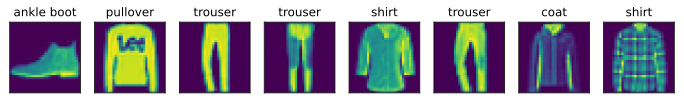

In [ ]:
@d2l.add_to_class(FashionMNIST)  #@ save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)

batch = next(iter(data.val_dataloader()))
data.visualize(batch)

We are now ready to work with the Fashion-MNIST dataset in the sections that follow.

### 4.2.4. Summary

We now have a slightly more realistic dataset to use for classification. Fashion-MNIST is an apparel classification dataset consisting of images representing 10 categories. We will use this dataset in subsequent sections and chapters to evaluate various network designs, from a simple linear model to advanced residual networks. As we commonly do with images, we read them as a tensor of shape (batch size, number of channels, height, width). For now, we only have one channel as the images are grayscale (the visualization above uses a false color palette for improved visibility).

Lastly, data iterators are a key component for efficient performance. For instance, we might use GPUs for efficient image decompression, video transcoding, or other preprocessing. Whenever possible, you should rely on well-implemented data iterators that exploit high-performance computing to avoid slowing down your training loop.

### 4.2.5. Exercises

1. Does reducing the `batch_size` (for instance, to 1) affect the reading performance?

1. The data iterator performance is important. Do you think the current implementation is fast enough? Explore various options to improve it. Use a system profiler to find out where the bottlenecks are.

1. Check out the framework's online API documentation. Which other datasets are available?

## 4.3. The Base Classification Model

You may have noticed that the implementations from scratch and the concise implementation using framework functionality were quite similar in the case of regression. The same is true for classification. Since many models in this book deal with classification, it is worth adding functionalities to support this setting specifically. This section provides a base class for classification models to simplify future code.

In [ ]:
import torch
from d2l import torch as d2l

### 4.3.1. The `Classifier` Class

We define the `Classifier` class below. In the `validation_step` we report both the loss value and the classification accuracy on a validation batch. We draw an update for every `num_val_batches` batches. This has the benefit of generating the averaged loss and accuracy on the whole validation data. These average numbers are not exactly correct if the final batch contains fewer examples, but we ignore this minor difference to keep the code simple.

In [ ]:
class Classifier(d2l.Module):  #@ save
    """The base class of classification models."""
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('acc', self.accuracy(Y_hat, batch[-1]), train=False)

By default we use a stochastic gradient descent optimizer, operating on minibatches, just as we did in the context of linear regression.

In [ ]:
@d2l.add_to_class(d2l.Module)  #@ save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), lr=self.lr)

### 4.3.2. Accuracy

Given the predicted probability distribution `y_hat`, we typically choose the class with the highest predicted probability whenever we must output a hard prediction. Indeed, many applications require that we make a choice. For instance, Gmail must categorize an email into "Primary", "Social", "Updates", "Forums", or "Spam". It might estimate probabilities internally, but at the end of the day it has to choose one among the classes.

When predictions are consistent with the label class `y`, they are correct. The classification accuracy is the fraction of all predictions that are correct. Although it can be difficult to optimize accuracy directly (it is not differentiable), it is often the performance measure that we care about the most. It is often *the* relevant quantity in benchmarks. As such, we will nearly always report it when training classifiers.

Accuracy is computed as follows. First, if `y_hat` is a matrix, we assume that the second dimension stores prediction scores for each class. We use `argmax` to obtain the predicted class by the index for the largest entry in each row. Then we compare the predicted class with the ground truth `y` elementwise. Since the equality operator `==` is sensitive to data types, we convert `y_hat`'s data type to match that of `y`. The result is a tensor containing entries of 0 (false) and 1 (true). Taking the sum yields the number of correct predictions.

In [ ]:
@d2l.add_to_class(Classifier)  #@ save
def accuracy(self, Y_hat, Y, averaged=True):
    """Compute the number of correct predictions."""
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    preds = Y_hat.argmax(axis=1).type(Y.dtype)
    compare = (preds == Y.reshape(-1)).type(torch.float32)
    return compare.mean() if averaged else compare

### 4.3.3. Summary

Classification is a sufficiently common problem that it warrants its own convenience functions. Of central importance in classification is the *accuracy* of the classifier. Note that while we often care primarily about accuracy, we train classifiers to optimize a variety of other objectives for statistical and computational reasons. However, regardless of which loss function was minimized during training, it is useful to have a convenience method for assessing the accuracy of our classifier empirically.

### 4.3.4. Exercises

1. Denote by $L_\textrm{v}$ the validation loss, and let $L_\textrm{v}^\textrm{q}$ be its quick and dirty estimate computed by the loss function averaging in this section. Lastly, denote by $l_\textrm{v}^\textrm{b}$ the loss on the last minibatch. Express $L_\textrm{v}$ in terms of $L_\textrm{v}^\textrm{q}$, $l_\textrm{v}^\textrm{b}$, and the sample and minibatch sizes.

1. Show that the quick and dirty estimate $L_\textrm{v}^\textrm{q}$ is unbiased. That is, show that $E[L_\textrm{v}] = E[L_\textrm{v}^\textrm{q}]$. Why would you still want to use $L_\textrm{v}$ instead?

1. Given a multiclass classification loss, denoting by $l(y,y')$ the penalty of estimating $y'$ when we see $y$ and given a probabilty $p(y \mid x)$, formulate the rule for an optimal selection of $y'$. Hint: express the expected loss, using $l$ and $p(y \mid x)$.

---
Q3 - 文心：在多类分类问题中，给定一个损失函数 $l(y, y')$，该函数衡量了当我们看到真实类别 $y$ 但预测为 $y'$ 时的惩罚。同时，给定了一个条件概率 $p(y \mid x)$，它表示在给定输入 $x$ 的情况下，输出为 $y$ 的概率。

为了选择最优的 $y'$ 以最小化期望损失，我们需要考虑所有可能的 $y'$ 并计算相应的期望损失。这里，期望损失（Expected Loss）是指在不同 $y$ 出现的概率下，预测为 $y'$ 所产生的损失的加权平均值。

具体地，最优的 $y'$ 应该是使得期望损失最小的那个类别。期望损失可以表达为：

$$
\text{Expected Loss} = \sum_{y \in \mathcal{Y}} p(y \mid x) \cdot l(y, y')
$$

其中，$\mathcal{Y}$ 是所有可能的类别集合。

为了找到最优的 $y'$，我们需要遍历所有可能的 $y' \in \mathcal{Y}$，计算上述期望损失，并选择使得期望损失最小的 $y'$。即：

$$
y'^{*} = \arg\min_{y' \in \mathcal{Y}} \sum_{y \in \mathcal{Y}} p(y \mid x) \cdot l(y, y')
$$

这里，$y'^{*}$ 就是我们要找的最优预测类别，它能够使得在给定输入 $x$ 和预测类别 $y'$ 下的期望损失最小。

注意，在实际应用中，由于 $p(y \mid x)$ 是通过模型（如神经网络）学习得到的，并且 $l(y, y')$ 是预先定义的损失函数（如交叉熵损失），因此这个优化过程通常是在模型的训练阶段通过最小化整个训练集的期望损失来完成的，而不是在每次预测时单独进行。但在预测时，我们会使用学习到的模型来计算 $p(y \mid x)$，并根据上述规则来选择最优的 $y'$。

## 4.4. Softmax Regression Implementation from Scratch

Because softmax regression is so fundamental, we believe that you ought to know how to implement it yourself. Here, we limit ourselves to defining the softmax-specific aspects of the model and reuse the other components from our linear regression section, including the training loop.

In [ ]:
import torch
from d2l import torch as d2l

### 4.4.1. The Softmax

Let's begin with the most important part: the mapping from scalars to probabilities. For a refresher, recall the operation of the sum operator along specific dimensions in a tensor,as discussed in Section 2.3.6 and Section 2.3.7. Given a matrix `X` we can sum over all elements (by default) or only over elements in the same axis. The `axis` variable lets us compute row and column sums:

In [ ]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdims=True), X.sum(1, keepdims=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

Computing the softmax requires three steps: (i) exponentiation of each term; (ii) a sum over each row to compute the normalization constant for each example; (iii) division of each row by its normalization constant, ensuring that the result sums to 1:

$$\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}. \tag{4.4.1}$$

The (logarithm of the) denominator is called the (log) *partition function*. It was introduced in [statistical physics](https://en.wikipedia.org/wiki/Partition_function_(statistical_mechanics)) to sum over all possible states in a thermodynamic ensemble. The implementation is straightforward:

In [ ]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdims=True)
    return X_exp / partition  # The broadcasting mechanism is applied here

For any input `X`, we turn each element into a nonnegative number. Each row sums up to 1, as is required for a probability. Caution: the code above is *not* robust against very large or very small arguments. While it is sufficient to illustrate what is happening, you should *not* use this code verbatim for any serious purpose. Deep learning frameworks have such protections built in and we will be using the built-in softmax going forward.

In [ ]:
X = torch.rand((2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1805, 0.1133, 0.2244, 0.2214, 0.2604],
         [0.1493, 0.1607, 0.2443, 0.2246, 0.2210]]),
 tensor([1.0000, 1.0000]))

### 4.4.2. The Model

We now have everything that we need to implement the softmax regression model. As in our linear regression example, each instance will be represented by a fixed-length vector. Since the raw data here consists of $28 \times 28$ pixel images, we flatten each image, treating them as vectors of length 784. In later chapters, we will introduce convolutional neural networks, which exploit the spatial structure in a more satisfying way.

In softmax regression, the number of outputs from our network should be equal to the number of classes. Since our dataset has 10 classes, our network has an output dimension of 10. Consequently, our weights constitute a $784 \times 10$ matrix plus a $1 \times 10$ row vector for the biases. As with linear regression, we initialize the weights `W` with Gaussian noise. The biases are initialized as zeros.

In [ ]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

The code below defines how the network maps each input to an output. Note that we flatten each $28 \times 28$ pixel image in the batch into a vector using `reshape` before passing the data through our model.

In [ ]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)

### 4.4.3. The Cross-Entropy Loss

Next we need to implement the cross-entropy loss function (introduced in Section 4.1.2). This may be the most common loss function in all of deep learning. At the moment, applications of deep learning easily cast as classification problems far outnumber those better treated as regression problems.

Recall that cross-entropy takes the negative log-likelihood of the predicted probability assigned to the true label. For efficiency we avoid Python for-loops and use indexing instead. In particular, the one-hot encoding in $\mathbf{y}$ allows us to select the matching terms in $\hat{\mathbf{y}}$.

To see this in action we create sample data `y_hat` with 2 examples of predicted probabilities over 3 classes and their corresponding labels `y`. The correct labels are $0$ and $2$ respectively (i.e., the first and third class). Using `y` as the indices of the probabilities in `y_hat`, we can pick out terms efficiently.

In [ ]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

Now we can implement the cross-entropy loss function by averaging over the logarithms of the selected probabilities.

In [ ]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

cross_entropy(y_hat, y)

tensor(1.4979)

In [ ]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

### 4.4.4. Training

We reuse the `fit` method defined in Section 3.4 to train the model with 10 epochs. Note that the number of epochs (`max_epochs`), the minibatch size (`batch_size`), and learning rate (`lr`) are adjustable hyperparameters. That means that while these values are not learned during our primary training loop, they still influence the performance of our model, both vis-à-vis training and generalization performance. In practice you will want to choose these values based on the *validation* split of the data and then, ultimately, to evaluate your final model on the *test* split. As discussed in Section 3.6.3, we will regard the test data of Fashion-MNIST as the validation set, thus reporting validation loss and validation accuracy on this split.

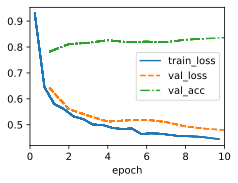

In [ ]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

### 4.4.5. Prediction

Now that training is complete, our model is ready to classify some images.

In [ ]:
X, y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([256])

We are more interested in the images we label *incorrectly*. We visualize them by comparing their actual labels (first line of text output) with the predictions from the model (second line of text output).

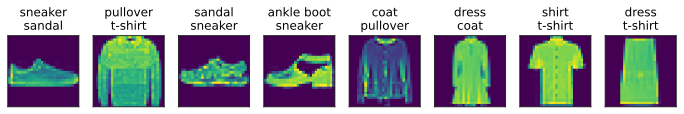

In [ ]:
wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)

---
牧之：翻看代码，因为这里提供了 `labels`，所以传入的 `y` 是没有实际作用的。`y` 的作用是在没有传入 `labels` 时提供 `label`。

### 4.4.6. Summary

By now we are starting to get some experience with solving linear regression and classification problems. With it, we have reached what would arguably be the state of the art of 1960--1970s of statistical modeling. In the next section, we will show you how to leverage deep learning frameworks to implement this model much more efficiently.

### 4.4.7. Exercises

1. In this section, we directly implemented the softmax function based on the mathematical definition of the softmax operation. As discussed in Section 4.1 this can cause numerical instabilities.
    - Test whether `softmax` still works correctly if an input has a value of $100$.
    - Test whether `softmax` still works correctly if the largest of all inputs is smaller than $-100$?
    - Implement a fix by looking at the value relative to the largest entry in the argument.

1. Implement a `cross_entropy` function that follows the definition of the cross-entropy loss function $\sum_i y_i \log \hat{y}_i$.
    - Try it out in the code example of this section.
    - Why do you think it runs more slowly?
    - Should you use it? When would it make sense to?
    - What do you need to be careful of? Hint: consider the domain of the logarithm.

1. Is it always a good idea to return the most likely label? For example, would you do this for medical diagnosis? How would you try to address this?

1. Assume that we want to use softmax regression to predict the next word based on some features. What are some problems that might arise from a large vocabulary?

1. Experiment with the hyperparameters of the code in this section. In particular:
    - Plot how the validation loss changes as you change the learning rate.
    - Do the validation and training loss change as you change the minibatch size? How large or small do you need to go before you see an effect?

---
Q4 - GPT：大词汇量可能会导致 softmax 回归的计算复杂度急剧增加，因为 softmax 函数的分母涉及对所有词汇的求和。此外，大词汇量还可能导致数据稀疏性和过拟合问题，因为模型需要处理大量罕见的词汇。当词汇量很大时，训练数据中对于每个单词的样本数量可能会相对较少。这意味着对于许多词汇，模型可能只能获得很少甚至零个样本，这被称为数据稀疏性。数据稀疏性会导致模型难以准确地学习罕见词汇的特征，因为它们可能只在很少的上下文中出现。这可能导致模型在处理罕见词汇时表现不佳，因为它们缺乏足够的信息来准确地进行预测。

## 4.5. Concise Implementation of Softmax Regression

Just as high-level deep learning frameworks made it easier to implement linear regression (see Section 3.5), they are similarly convenient here.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 4.5.1. Defining the Model

As in Section 3.5, we construct our fully connected layer using the built-in layer. The built-in `__call__` method then invokes `forward` whenever we need to apply the network to some input. We use a `Flatten` layer to convert the fourth-order tensor `X` to second order by keeping the dimensionality along the first axis unchanged.

In [ ]:
class SoftmaxRegression(d2l.Classifier):  #@ save
    """The softmax regression model."""
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))

    def forward(self, X):
        return self.net(X)

### 4.5.2. Softmax Revisited

In Section 4.4 we calculated our model's output and applied the cross-entropy loss. While this is perfectly reasonable mathematically, it is risky computationally, because of numerical underflow and overflow in the exponentiation.

Recall that the softmax function computes probabilities via $\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$. If some of the $o_k$ are very large, i.e., very positive, then $\exp(o_k)$ might be larger than the largest number we can have for certain data types. This is called *overflow*. Likewise, if every argument is a very large negative number, we will get *underflow*. For instance, single precision floating point numbers approximately cover the range of $10^{-38}$ to $10^{38}$. As such, if the largest term in $\mathbf{o}$ lies outside the interval $[-90, 90]$, the result will not be stable. A way round this problem is to subtract $\bar{o} \stackrel{\textrm{def}}{=} \max_k o_k$ from all entries:

$$
\hat y_j = \frac{\exp o_j}{\sum_k \exp o_k} =
\frac{\exp(o_j - \bar{o}) \exp \bar{o}}{\sum_k \exp (o_k - \bar{o}) \exp \bar{o}} =
\frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})}. \tag{4.5.1}
$$

By construction we know that $o_j - \bar{o} \leq 0$ for all $j$. As such, for a $q$-class classification problem, the denominator is contained in the interval $[1, q]$. Moreover, the numerator never exceeds $1$, thus preventing numerical overflow. Numerical underflow only occurs when $\exp(o_j - \bar{o})$ numerically evaluates as $0$. Nonetheless, a few steps down the road we might find ourselves in trouble when we want to compute $\log \hat{y}_j$ as $\log 0$. In particular, in backpropagation, we might find ourselves faced with a screenful of the dreaded `NaN` (Not a Number) results.

Fortunately, we are saved by the fact that even though we are computing exponential functions, we ultimately intend to take their log (when calculating the cross-entropy loss). By combining softmax and cross-entropy, we can escape the numerical stability issues altogether. We have:

$$
\log \hat{y}_j =
\log \frac{\exp(o_j - \bar{o})}{\sum_k \exp (o_k - \bar{o})} =
o_j - \bar{o} - \log \sum_k \exp (o_k - \bar{o}). \tag{4.5.2}
$$

This avoids both overflow and underflow. We will want to keep the conventional softmax function handy in case we ever want to evaluate the output probabilities by our model. But instead of passing softmax probabilities into our new loss function, we just pass the logits and compute the softmax and its log all at once inside the cross-entropy loss function, which does smart things like the ["LogSumExp trick"](https://en.wikipedia.org/wiki/LogSumExp).

---
牧之：在公式 (4.5.2) 里，某个 $\exp (o_k - \bar{o})$ 可能趋于 0，但对全部类别求和之后就不会趋于 0。

In [ ]:
@d2l.add_to_class(d2l.Classifier)  #@ save
def loss(self, Y_hat, Y, averaged=True):
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    Y = Y.reshape((-1,))
    return F.cross_entropy(
        Y_hat, Y, reduction='mean' if averaged else 'none')

### 4.5.3. Training

Next we train our model. We use Fashion-MNIST images, flattened to 784-dimensional feature vectors.

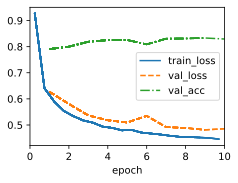

In [ ]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegression(num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

As before, this algorithm converges to a solution that is reasonably accurate, albeit this time with fewer lines of code than before.

### 4.5.4. Summary

High-level APIs are very convenient at hiding from their user potentially dangerous aspects, such as numerical stability. Moreover, they allow users to design models concisely with very few lines of code. This is both a blessing and a curse. The obvious benefit is that it makes things highly accessible, even to engineers who never took a single class of statistics in their life (in fact, they are part of the target audience of the book). But hiding the sharp edges also comes with a price: a disincentive to add new and different components on your own, since there is little muscle memory for doing it. Moreover, it makes it more difficult to *fix* things whenever the protective padding of a framework fails to cover all the corner cases entirely. Again, this is due to lack of familiarity.

As such, we strongly urge you to review *both* the bare bones and the elegant versions of many of the implementations that follow. While we emphasize ease of understanding, the implementations are nonetheless usually quite performant (convolutions are the big exception here). It is our intention to allow you to build on these when you invent something new that no framework can give you.

### 4.5.5. Exercises

1. Deep learning uses many different number formats, including FP64 double precision (used extremely rarely), FP32 single precision, BFLOAT16 (good for compressed representations), FP16 (very unstable), TF32 (a new format from NVIDIA), and INT8. Compute the smallest and largest argument of the exponential function for which the result does not lead to numerical underflow or overflow.

1. INT8 is a very limited format consisting of nonzero numbers from $1$ to $255$. How could you extend its dynamic range without using more bits? Do standard multiplication and addition still work?

1. Increase the number of epochs for training. Why might the validation accuracy decrease after a while? How could we fix this?

1. What happens as you increase the learning rate? Compare the loss curves for several learning rates. Which one works better? When?

## 4.6. Generalization in Classification

So far, we have focused on how to tackle multiclass classification problems by training (linear) neural networks with multiple outputs and softmax functions. Interpreting our model's outputs as probabilistic predictions, we motivated and derived the cross-entropy loss function, which calculates the negative log likelihood that our model (for a fixed set of parameters) assigns to the actual labels. And finally, we put these tools into practice by fitting our model to the training set. However, as always, our goal is to learn *general patterns*, as assessed empirically on previously unseen data (the test set). High accuracy on the training set means nothing. Whenever each of our inputs is unique (and indeed this is true for most high-dimensional datasets), we can attain perfect accuracy on the training set by just memorizing the dataset on the first training epoch, and subsequently looking up the label whenever we see a new image. And yet, memorizing the exact labels associated with the exact training examples does not tell us how to classify new examples. Absent further guidance, we might have to fall back on random guessing whenever we encounter new examples.

A number of burning questions demand immediate attention:

1. How many test examples do we need to give a good estimate of the accuracy of our classifiers on the underlying population?
1. What happens if we keep evaluating models on the same test repeatedly?
1. Why should we expect that fitting our linear models to the training set should fare any better than our naive memorization scheme?

Whereas Section 3.6 introduced the basics of overfitting and generalization in the context of linear regression, this chapter will go a little deeper, introducing some of the foundational ideas of statistical learning theory. It turns out that we often can guarantee generalization *a priori*: for many models, and for any desired upper bound on the generalization gap $\epsilon$, we can often determine some required number of samples $n$ such that if our training set contains at least $n$ samples, our empirical error will lie within $\epsilon$ of the true error, *for any data generating distribution*. Unfortunately, it also turns out that while these sorts of guarantees provide a profound set of intellectual building blocks, they are of limited practical utility to the deep learning practitioner. In short, these guarantees suggest that ensuring generalization of deep neural networks *a priori* requires an absurd number of examples (perhaps trillions or more), even when we find that, on the tasks we care about, deep neural networks typically generalize remarkably well with far fewer examples (thousands). Thus deep learning practitioners often forgo *a priori* guarantees altogether, instead employing methods that have generalized well on similar problems in the past, and certifying generalization *post hoc* through empirical evaluations. When we get to Section 5, we will revisit generalization and provide a light introduction to the vast scientific literature that has sprung in attempts to explain why deep neural networks generalize in practice.

### 4.6.1. The Test Set

Since we have already begun to rely on test sets as the gold standard method for assessing generalization error, let's get started by discussing the properties of such error estimates. Let's focus on a fixed classifier $f$, without worrying about how it was obtained. Moreover suppose that we possess a *fresh* dataset of examples $\mathcal{D} = {(\mathbf{x}^{(i)},y^{(i)})}_{i=1}^n$ that were not used to train the classifier $f$. The *empirical error* of our classifier $f$ on $\mathcal{D}$ is simply the fraction of instances for which the prediction $f(\mathbf{x}^{(i)})$ disagrees with the true label $y^{(i)}$, and is given by the following expression:

$$\epsilon_\mathcal{D}(f) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}(f(\mathbf{x}^{(i)}) \neq y^{(i)}). \tag{4.6.1}$$

By contrast, the *population error* is the *expected* fraction of examples in the underlying population (some distribution $P(X,Y)$  characterized by probability density function $p(\mathbf{x},y)$) for which our classifier disagrees with the true label:

$$\epsilon(f) =  E_{(\mathbf{x}, y) \sim P} \mathbf{1}(f(\mathbf{x}) \neq y) = \int\int \mathbf{1}(f(\mathbf{x}) \neq y) p(\mathbf{x}, y) \;d\mathbf{x} dy. \tag{4.6.2}$$

While $\epsilon(f)$ is the quantity that we actually care about, we cannot observe it directly, just as we cannot directly observe the average height in a large population without measuring every single person. We can only estimate this quantity based on samples. Because our test set $\mathcal{D}$ is statistically representative of the underlying population, we can view $\epsilon_\mathcal{D}(f)$ as a statistical estimator of the population error $\epsilon(f)$. Moreover, because our quantity of interest $\epsilon(f)$ is an expectation (of the random variable $\mathbf{1}(f(X) \neq Y)$) and the corresponding estimator $\epsilon_\mathcal{D}(f)$ is the sample average, estimating the population error is simply the classic problem of mean estimation, which you may recall from Section 2.6.

An important classical result from probability theory called the *central limit theorem* guarantees that whenever we possess $n$ random samples $a_1, ..., a_n$ drawn from *any* distribution with mean $\mu$ and standard deviation $\sigma$, then, as the number of samples $n$ approaches infinity, the sample average $\hat{\mu}$ approximately tends towards a normal distribution centered at the true mean and with standard deviation $\sigma/\sqrt{n}$. Already, this tells us something important: as the number of examples grows large, our test error $\epsilon_\mathcal{D}(f)$ should approach the true error $\epsilon(f)$ at *a rate of* $\mathcal{O}(1/\sqrt{n})$. Thus, to estimate our test error twice as precisely, we must collect four times as large a test set. To reduce our test error by a factor of one hundred, we must collect ten thousand times as large a test set. In general, such a rate of $\mathcal{O}(1/\sqrt{n})$ is often the best we can hope for in statistics.

Now that we know something about the asymptotic rate at which our test error $\epsilon_\mathcal{D}(f)$ converges to the true error $\epsilon(f)$, we can zoom in on some important details. Recall that the random variable of interest $\mathbf{1}(f(X) \neq Y)$ can only take values $0$ and $1$ and thus is a Bernoulli random variable, characterized by a parameter indicating the probability that it takes value $1$. Here, $1$ means that our classifier made an error, so the parameter of our random variable is actually the true error rate $\epsilon(f)$. The variance $\sigma^2$ of a Bernoulli depends on its parameter (here, $\epsilon(f)$) according to the expression $\epsilon(f)(1-\epsilon(f))$. While $\epsilon(f)$ is initially unknown, we know that it cannot be greater than $1$. A little investigation of this function reveals that our variance is highest when the true error rate is close to $0.5$ and can be far lower when it is close to $0$ or close to $1$. This tells us that the asymptotic standard deviation of our estimate $\epsilon_\mathcal{D}(f)$ of the error $\epsilon(f)$ (over the choice of the $n$ test samples) cannot be any greater than $\sqrt{0.25/n}$.

If we ignore the fact that this rate characterizes behavior as the test set size approaches infinity rather than when we possess finite samples, this tells us that if we want our test error $\epsilon_\mathcal{D}(f)$ to approximate the population error $\epsilon(f)$ such that one standard deviation corresponds to an interval of $\pm 0.01$, then we should collect roughly 2500 samples. If we want to fit two standard deviations in that range and thus be 95% confident that $\epsilon_\mathcal{D}(f) \in \epsilon(f) \pm 0.01$, then we will need 10,000 samples!

This turns out to be the size of the test sets for many popular benchmarks in machine learning. You might be surprised to find out that thousands of applied deep learning papers get published every year making a big deal out of error rate improvements of $0.01$ or less. Of course, when the error rates are much closer to $0$, then an improvement of $0.01$ can indeed be a big deal.

---
牧之：精彩！

One pesky feature of our analysis thus far is that it really only tells us about asymptotics, i.e., how the relationship between $\epsilon_\mathcal{D}$ and $\epsilon$ evolves as our sample size goes to infinity. Fortunately, because our random variable is bounded, we can obtain valid finite sample bounds by applying an inequality due to Hoeffding (1963):

$$P(\epsilon_\mathcal{D}(f) - \epsilon(f) \geq t) < \exp\left( - 2n t^2 \right). \tag{4.6.3}$$

Solving for the smallest dataset size that would allow us to conclude with 95% confidence that the distance $t$ between our estimate $\epsilon_\mathcal{D}(f)$ and the true error rate $\epsilon(f)$ does not exceed $0.01$, you will find that roughly 15,000 examples are required as compared to the 10,000 examples suggested by the asymptotic analysis above. If you go deeper into statistics you will find that this trend holds generally. Guarantees that hold even in finite samples are typically slightly more conservative. Note that in the scheme of things, these numbers are not so far apart, reflecting the general usefulness of asymptotic analysis for giving us ballpark figures even if they are not guarantees we can take to court.

### 4.6.2. Test Set Reuse

In some sense, you are now set up to succeed at conducting empirical machine learning research. Nearly all practical models are developed and validated based on test set performance and you are now a master of the test set. For any fixed classifier $f$, you know how to evaluate its test error $\epsilon_\mathcal{D}(f)$, and know precisely what can (and cannot) be said about its population error $\epsilon(f)$.

So let's say that you take this knowledge and prepare to train your first model $f_1$. Knowing just how confident you need to be in the performance of your classifier's error rate you apply our analysis above to determine an appropriate number of examples to set aside for the test set. Moreover, let's assume that you took the lessons from Section 3.6 to heart and made sure to preserve the sanctity of the test set by conducting all of your preliminary analysis, hyperparameter tuning, and even selection among multiple competing model architectures on a validation set. Finally you evaluate your model $f_1$ on the test set and report an unbiased estimate of the population error with an associated confidence interval.

So far everything seems to be going well. However, that night you wake up at 3am with a brilliant idea for a new modeling approach. The next day, you code up your new model, tune its hyperparameters on the validation set and not only are you getting your new model $f_2$ to work but its error rate appears to be much lower than $f_1$'s. However, the thrill of discovery suddenly fades as you prepare for the final evaluation. You do not have a test set!

Even though the original test set $\mathcal{D}$ is still sitting on your server, you now face two formidable problems. First, when you collected your test set, you determined the required level of precision under the assumption that you were evaluating a single classifier $f$. However, if you get into the business of evaluating multiple classifiers $f_1, ..., f_k$ on the same test set, you must consider the problem of false discovery. Before, you might have been 95% sure that $\epsilon_\mathcal{D}(f) \in \epsilon(f) \pm 0.01$ for a single classifier $f$ and thus the probability of a misleading result was a mere 5%. With $k$ classifiers in the mix, it can be hard to guarantee that there is not even one among them whose test set performance is misleading. With 20 classifiers under consideration, you might have no power at all to rule out the possibility that at least one among them received a misleading score. This problem relates to multiple hypothesis testing, which despite a vast literature in statistics, remains a persistent problem plaguing scientific research.

---
牧之：是指一个测试集如果被用于测试多个模型，则置信度这个值，会变得不可靠吗？

GPT：是的，当一个测试集被用于测试多个模型时，置信度的值会变得不太可靠。当进行多个模型的测试时，原本针对单个模型的置信度水平可能不再适用，因为多次测试会增加出现偶然性误差的可能性。这会导致在评估多个模型时，原有的置信度水平可能不再准确反映测试结果的可靠性。因此，当同一个测试集被用于测试多个模型时，需要谨慎考虑置信度值，并可能需要采取一些多重假设检验的方法，以确保得出的结论具有可靠性。这包括对多重比较进行校正以及控制误发现率，以确保在评估多个模型时不会错误地得出结论。

If that is not enough to worry you, there is a special reason to distrust the results that you get on subsequent evaluations. Recall that our analysis of test set performance rested on the assumption that the classifier was chosen absent any contact with the test set and thus we could view the test set as drawn randomly from the underlying population. Here, not only are you testing multiple functions, the subsequent function $f_2$ was chosen after you observed the test set performance of $f_1$. *Once information from the test set has leaked to the modeler, it can never be a true test set again in the strictest sense*. This problem is called *adaptive overfitting* and has recently emerged as a topic of intense interest to learning theorists and statisticians (Dwork et al., 2015). Fortunately, while it is possible to leak all information out of a holdout set, and the theoretical worst case scenarios are bleak, these analyses may be too conservative. In practice, take care to create real test sets, to consult them as infrequently as possible, to account for multiple hypothesis testing when reporting confidence intervals, and to dial up your vigilance more aggressively when the stakes are high and your dataset size is small. When running a series of benchmark challenges, it is often good practice to maintain several test sets so that after each round, the old test set can be demoted to a validation set.

---
牧之：貌似这个可以作为持续数据采集非常重要的一个底层理论依据。
- 为了保证置信度，需要有一个比较大的测试集。
- 每个测试集只能使用一次，用过的测试集可以转做验证集。

那就意味着我们需要不停采集数据生产测试集。

### 4.6.3. Statistical Learning Theory

Put simply, *test sets are all that we really have*, and yet this fact seems strangely unsatisfying. First, we seldom possess a *true test set*---unless we are the ones creating the dataset, someone else has probably already evaluated their own classifier on our ostensible "test set". And even when we have first dibs, we soon find ourselves frustrated, wishing we could evaluate our subsequent modeling attempts without the gnawing feeling that we cannot trust our numbers. Moreover, even a true test set can only tell us *post hoc* whether a classifier has in fact generalized to the population, not whether we have any reason to expect *a priori* that it should generalize.

With these misgivings in mind, you might now be sufficiently primed to see the appeal of *statistical learning theory*, the mathematical subfield of machine learning whose practitioners aim to elucidate the fundamental principles that explain why/when models trained on empirical data can/will generalize to unseen data. One of the primary aims of statistical learning researchers has been to bound the generalization gap, relating the properties of the model class to the number of samples in the dataset.

Learning theorists aim to bound the difference between the *empirical error* $\epsilon_\mathcal{S}(f_\mathcal{S})$ of a learned classifier $f_\mathcal{S}$, both trained and evaluated on the training set $\mathcal{S}$, and the true error $\epsilon(f_\mathcal{S})$ of that same classifier on the underlying population. This might look similar to the evaluation problem that we just addressed but there is a major difference. Earlier, the classifier $f$ was fixed and we only needed a dataset for evaluative purposes. And indeed, any fixed classifier does generalize: its error on a (previously unseen) dataset is an unbiased estimate of the population error. But what can we say when a classifier is trained and evaluated on the same dataset? Can we ever be confident that the training error will be close to the testing error?

Suppose that our learned classifier $f_\mathcal{S}$ must be chosen from some pre-specified set of functions $\mathcal{F}$. Recall from our discussion of test sets that while it is easy to estimate the error of a single classifier, things get hairy when we begin to consider collections of classifiers. Even if the empirical error of any one (fixed) classifier will be close to its true error with high probability, once we consider a collection of classifiers, we need to worry about the possibility that *just one* of them will receive a badly estimated error. The worry is that we might pick such a classifier and thereby grossly underestimate the population error. Moreover, even for linear models, because their parameters are continuously valued, we are typically choosing from an infinite class of functions ($|\mathcal{F}| = \infty$).

One ambitious solution to the problem is to develop analytic tools for proving uniform convergence, i.e., that with high probability, the empirical error rate for every classifier in the class $f\in\mathcal{F}$ will *simultaneously* converge to its true error rate. In other words, we seek a theoretical principle that would allow us to state that with probability at least $1-\delta$ (for some small $\delta$) no classifier's error rate $\epsilon(f)$ (among all classifiers in the class $\mathcal{F}$) will be misestimated by more than some  small amount $\alpha$. Clearly, we cannot make such statements for all model classes $\mathcal{F}$. Recall the class of memorization machines that always achieve empirical error $0$ but never outperform random guessing on the underlying population.

In a sense the class of memorizers is too flexible. No such a uniform convergence result could possibly hold. On the other hand, a fixed classifier is useless---it generalizes perfectly, but fits neither the training data nor the test data. The central question of learning has thus historically been framed as a trade-off between more flexible (higher variance) model classes that better fit the training data but risk overfitting, versus more rigid (higher bias) model classes that generalize well but risk underfitting. A central question in learning theory has been to develop the appropriate mathematical analysis to quantify where a model sits along this spectrum, and to provide the associated guarantees.

---
牧之：中文深度解读这段话的含义，包括其深意。

GPT：这段话探讨了机器学习中关于模型灵活性与泛化能力之间权衡的核心问题。
- "In a sense the class of memorizers is too flexible." — 这里指的是那些能够准确记住训练集每一个细节的模型类别（memorizers），它们在训练集上表现非常好，但可能在未知数据上泛化能力差。
- "No such a uniform convergence result could possibly hold." — 指的是这类模型通常不会有统一的收敛结果（uniform convergence），即它们的训练误差与测试误差之间的差距可能会很大。
- "A fixed classifier is useless" — 指的是某些过于刚性的分类器，它们在训练数据和测试数据上表现都很差，即使在训练数据上和测试数据上的误差都很大，但它们在理论上可以完美泛化。
- "Framed as a trade-off between more flexible (higher variance) model classes" — 把学习看作是在灵活性更高（方差更大）的模型类别和更刚性（偏差更大）的模型类别之间进行权衡。
- "That better fit the training data but risk overfitting" — 灵活性高的模型更容易拟合训练数据，但可能存在过拟合的风险。
- "Versus more rigid (higher bias) model classes that generalize well but risk underfitting" — 偏差较高的模型虽然泛化能力较强，但容易出现欠拟合问题。
- "To develop the appropriate mathematical analysis" — 开发适当的数学分析方法。
- "To quantify where a model sits along this spectrum" — 量化模型在灵活性和泛化能力之间的位置。

In a series of seminal papers, Vapnik and Chervonenkis extended the theory on the convergence of relative frequencies to more general classes of functions (Vapnik and Chervonenkis, 1964, Vapnik and Chervonenkis, 1968, Vapnik and Chervonenkis, 1971, Vapnik and Chervonenkis, 1981, Vapnik and Chervonenkis, 1991, Vapnik and Chervonenkis, 1974). One of the key contributions of this line of work is the Vapnik--Chervonenkis (VC) dimension, which measures (one notion of) the complexity (flexibility) of a model class. Moreover, one of their key results bounds the difference between the empirical error and the population error as a function of the VC dimension and the number of samples:

$$P\left(R[p, f] - R_\textrm{emp}[\mathbf{X}, \mathbf{Y}, f] < \alpha\right) \geq 1-\delta \ \textrm{ for }\ \alpha \geq c \sqrt{(\textrm{VC} - \log \delta)/n}. \tag{4.6.4}$$

Here $\delta > 0$ is the probability that the bound is violated, $\alpha$ is the upper bound on the generalization gap, and $n$ is the dataset size. Lastly, $c > 0$ is a constant that depends only on the scale of the loss that can be incurred. One use of the bound might be to plug in desired values of $\delta$ and $\alpha$ to determine how many samples to collect. The VC dimension quantifies the largest number of data points for which we can assign any arbitrary (binary) labeling and for each find some model $f$ in the class that agrees with that labeling. For example, linear models on $d$-dimensional inputs have VC dimension $d+1$. It is easy to see that a line can assign any possible labeling to three points in two dimensions, but not to four. Unfortunately, the theory tends to be overly pessimistic for more complex models and obtaining this guarantee typically requires far more examples than are actually needed to achieve the desired error rate. Note also that fixing the model class and $\delta$, our error rate again decays with the usual $\mathcal{O}(1/\sqrt{n})$ rate. It seems unlikely that we could do better in terms of $n$. However, as we vary the model class, VC dimension can present a pessimistic picture of the generalization gap.

---
牧之：这段没看太懂，可以参考阅读：https://tangshusen.me/2018/12/09/vc-dimension/

### 4.6.4. Summary

The most straightforward way to evaluate a model is to consult a test set comprised of previously unseen data. Test set evaluations provide an unbiased estimate of the true error and converge at the desired $\mathcal{O}(1/\sqrt{n})$ rate as the test set grows. We can provide approximate confidence intervals based on exact asymptotic distributions or valid finite sample confidence intervals based on (more conservative) finite sample guarantees. Indeed test set evaluation is the bedrock of modern machine learning research. However, test sets are seldom true test sets (used by multiple researchers again and again). Once the same test set is used to evaluate multiple models, controlling for false discovery can be difficult. This can cause huge problems in theory. In practice, the significance of the problem depends on the size of the holdout sets in question and whether they are merely being used to choose hyperparameters or if they are leaking information more directly. Nevertheless, it is good practice to curate real test sets (or multiple) and to be as conservative as possible about how often they are used.

Hoping to provide a more satisfying solution, statistical learning theorists have developed methods for guaranteeing uniform convergence over a model class. If indeed every model's empirical error simultaneously converges to its true error, then we are free to choose the model that performs best, minimizing the training error, knowing that it too will perform similarly well on the holdout data. Crucially, any one of such results must depend on some property of the model class. Vladimir Vapnik and Alexey Chernovenkis introduced the VC dimension, presenting uniform convergence results that hold for all models in a VC class. The training errors for all models in the class are (simultaneously) guaranteed to be close to their true errors, and guaranteed to grow even closer at $\mathcal{O}(1/\sqrt{n})$ rates. Following the revolutionary discovery of VC dimension, numerous alternative complexity measures have been proposed, each facilitating an analogous generalization guarantee. See Boucheron et al. (2005) for a detailed discussion of several advanced ways of measuring function complexity. Unfortunately, while these complexity measures have become broadly useful tools in statistical theory, they turn out to be powerless (as straightforwardly applied) for explaining why deep neural networks generalize. Deep neural networks often have millions of parameters (or more), and can easily assign random labels to large collections of points. Nevertheless, they generalize well on practical problems and, surprisingly, they often generalize better, when they are larger and deeper, despite incurring higher VC dimensions. In the next chapter, we will revisit generalization in the context of deep learning.

---
牧之：理论和实际有点脱节了，人们可能也无法预知深度神经网络为什么能成功，但事实就是它成功了。

### 4.6.5. Exercises

1. If we wish to estimate the error of a fixed model $f$ to within $0.0001$ with probability greater than 99.9%, how many samples do we need?

1. Suppose that somebody else possesses a labeled test set $\mathcal{D}$ and only makes available the unlabeled inputs (features). Now suppose that you can only access the test set labels by running a model $f$ (with no restrictions placed on the model class) on each of the unlabeled inputs and receiving the corresponding error $\epsilon_\mathcal{D}(f)$. How many models would you need to evaluate before you leak the entire test set and thus could appear to have error $0$, regardless of your true error?

1. What is the VC dimension of the class of fifth-order polynomials?

1. What is the VC dimension of axis-aligned rectangles on two-dimensional data?

## 4.7. Environment and Distribution Shift

In the previous sections, we worked through a number of hands-on applications of machine learning, fitting models to a variety of datasets. And yet, we never stopped to contemplate either where data came from in the first place or what we ultimately plan to do with the outputs from our models. Too often, machine learning developers in possession of data rush to develop models without pausing to consider these fundamental issues.

Many failed machine learning deployments can be traced back to this failure. Sometimes models appear to perform marvelously as measured by test set accuracy but fail catastrophically in deployment when the distribution of data suddenly shifts. More insidiously, sometimes the very deployment of a model can be the catalyst that perturbs the data distribution. Say, for example, that we trained a model to predict who will repay rather than default on a loan, finding that an applicant’s choice of footwear was associated with the risk of default (Oxfords indicate repayment, sneakers indicate default). We might be inclined thereafter to grant a loan to any applicant wearing Oxfords and to deny all applicants wearing sneakers.

In this case, our ill-considered leap from pattern recognition to decision-making and our failure to critically consider the environment might have disastrous consequences. For starters, as soon as we began making decisions based on footwear, customers would catch on and change their behavior. Before long, all applicants would be wearing Oxfords, without any coincident improvement in credit-worthiness. Take a minute to digest this because similar issues abound in many applications of machine learning: by introducing our model-based decisions to the environment, we might break the model.

---
牧之：传统程序会好一些吗？有可能，因为模型蕴含的能力，与传统程序相比，是高度数值化的。

While we cannot possibly give these topics a complete treatment in one section, we aim here to expose some common concerns, and to stimulate the critical thinking required to detect such situations early, mitigate damage, and use machine learning responsibly. Some of the solutions are simple (ask for the “right” data), some are technically difficult (implement a reinforcement learning system), and others require that we step outside the realm of statistical prediction altogether and grapple with difficult philosophical questions concerning the ethical application of algorithms.

### 4.7.1. Types of Distribution Shift

To begin, we stick with the passive prediction setting considering the various ways that data distributions might shift and what might be done to salvage model performance. In one classic setup, we assume that our training data was sampled from some distribution $p_S(\mathbf{x},y)$ but that our test data will consist of unlabeled examples drawn from some different distribution $p_T(\mathbf{x},y)$. Already, we must confront a sobering reality. Absent any assumptions on how $p_S$ and $p_T$ relate to each other, learning a robust classifier is impossible.

Consider a binary classification problem, where we wish to distinguish between dogs and cats. If the distribution can shift in arbitrary ways, then our setup permits the pathological case in which the distribution over inputs remains constant: $p_S(\mathbf{x}) = p_T(\mathbf{x})$, but the labels are all flipped: $p_S(y \mid \mathbf{x}) = 1 - p_T(y \mid \mathbf{x})$. In other words, if God can suddenly decide that in the future all "cats" are now dogs and what we previously called "dogs" are now cats---without any change in the distribution of inputs $p(\mathbf{x})$, then we cannot possibly distinguish this setting from one in which the distribution did not change at all.

Fortunately, under some restricted assumptions on the ways our data might change in the future, principled algorithms can detect shift and sometimes even adapt on the fly, improving on the accuracy of the original classifier.

#### 4.7.1.1. Covariate Shift

Among categories of distribution shift, covariate shift may be the most widely studied. Here, we assume that while the distribution of inputs may change over time, the labeling function, i.e., the conditional distribution $P(y \mid \mathbf{x})$ does not change. Statisticians call this *covariate shift* because the problem arises due to a shift in the distribution of the covariates (features). While we can sometimes reason about distribution shift without invoking causality, we note that covariate shift is the natural assumption to invoke in settings where we believe that $\mathbf{x}$ causes $y$.

Consider the challenge of distinguishing cats and dogs. Our training data might consist of images of the kind in Fig. 4.7.1.

<p align="center">
  <img src="https://d2l.ai/_images/cat-dog-train.png"/>
  <br />
  <em>Fig. 4.7.1</em>  Training data for distinguishing cats and dogs (illustrations: Lafeez Hossain / 500px / Getty Images; ilkermetinkursova / iStock / Getty Images Plus; GlobalP / iStock / Getty Images Plus; Musthafa Aboobakuru / 500px / Getty Images).
</p>

At test time we are asked to classify the images in Fig. 4.7.2.

<p align="center">
  <img src="https://d2l.ai/_images/cat-dog-test.png"/>
  <br />
  <em>Fig. 4.7.2</em> Test data for distinguishing cats and dogs (illustrations: SIBAS_minich / iStock / Getty Images Plus; Ghrzuzudu / iStock / Getty Images Plus; id-work / DigitalVision Vectors / Getty Images; Yime / iStock / Getty Images Plus).
</p>

The training set consists of photos, while the test set contains only cartoons. Training on a dataset with substantially different characteristics from the test set can spell trouble absent a coherent plan for how to adapt to the new domain.

#### 4.7.1.2. Label Shift

*Label shift* describes the converse problem. Here, we assume that the label marginal $P(y)$ can change but the class-conditional distribution $P(\mathbf{x} \mid y)$ remains fixed across domains. Label shift is a reasonable assumption to make when we believe that $y$ causes $\mathbf{x}$. For example, we may want to predict diagnoses given their symptoms (or other manifestations), even as the relative prevalence of diagnoses are changing over time. Label shift is the appropriate assumption here because diseases cause symptoms. In some degenerate cases the label shift and covariate shift assumptions can hold simultaneously. For example, when the label is deterministic, the covariate shift assumption will be satisfied, even when $y$ causes $\mathbf{x}$. Interestingly, in these cases, it is often advantageous to work with methods that flow from the label shift assumption. That is because these methods tend to involve manipulating objects that look like labels (often low-dimensional), as opposed to objects that look like inputs, which tend to be high-dimensional in deep learning.

---
GPT：当标签是确定性的情况下，covariate shift 假设也会被满足，即使 y 导致 x。这个概念在生活中可能有些抽象，这里给一个更具体的例子：假设你在进行一项健康研究，想要预测某种疾病的发病率。你从一个特定年代的医疗数据中获取了症状和疾病的对应关系，然后用这些数据进行预测。然而，随着时间的推移，不同疾病的相对发病率可能发生了变化，但是症状和疾病之间的关系仍然保持不变。在这种情况下，即使疾病引起了特定的症状（即 y 导致 x），由于标签是确定性的（即疾病和症状的对应关系保持不变），covariate shift 假设仍然成立。这个例子说明了即使疾病引起了某些特定的症状，但由于标签是确定性的，因此症状和疾病之间的关系仍然可以被视为满足 covariate shift 假设。

#### 4.7.1.3. Concept Shift

We may also encounter the related problem of *concept shift*, which arises when the very definitions of labels can change. This sounds weird---a *cat* is a *cat*, no? However, other categories are subject to changes in usage over time. Diagnostic criteria for mental illness, what passes for fashionable, and job titles, are all subject to considerable amounts of concept shift. It turns out that if we navigate around the United States, shifting the source of our data by geography, we will find considerable concept shift regarding the distribution of names for *soft drinks* as shown in Fig. 4.7.3.

<center></center>

<p align="center">
  <img src="https://d2l.ai/_images/popvssoda.png"/>
  <br />
  <em>Fig. 4.7.3</em>  Concept shift for soft drink names in the United States (CC-BY: Alan McConchie, PopVsSoda.com).
</p>

If we were to build a machine translation system, the distribution $P(y \mid \mathbf{x})$ might be different depending on our location. This problem can be tricky to spot. We might hope to exploit knowledge that shift only takes place gradually either in a temporal or geographic sense.

### 4.7.2. Examples of Distribution Shift

Before delving into formalism and algorithms, we can discuss some concrete situations where covariate or concept shift might not be obvious.

#### 4.7.2.1. Medical Diagnostics

Imagine that you want to design an algorithm to detect cancer. You collect data from healthy and sick people and you train your algorithm. It works fine, giving you high accuracy and you conclude that you are ready for a successful career in medical diagnostics. *Not so fast.*

The distributions that gave rise to the training data and those you will encounter in the wild might differ considerably. This happened to an unfortunate startup that some of we authors worked with years ago. They were developing a blood test for a disease that predominantly affects older men and hoped to study it using blood samples that they had collected from patients. However, it is considerably more difficult to obtain blood samples from healthy men than from sick patients already in the system. To compensate, the startup solicited blood donations from students on a university campus to serve as healthy controls in developing their test. Then they asked whether we could help them to build a classifier for detecting the disease.

As we explained to them, it would indeed be easy to distinguish between the healthy and sick cohorts with near-perfect accuracy. However, that is because the test subjects differed in age, hormone levels, physical activity, diet, alcohol consumption, and many more factors unrelated to the disease. This was unlikely to be the case with real patients. Due to their sampling procedure, we could expect to encounter extreme covariate shift. Moreover, this case was unlikely to be correctable via conventional methods. In short, they wasted a significant sum of money.

#### 4.7.2.2. Self-Driving Cars

Say a company wanted to leverage machine learning for developing self-driving cars. One key component here is a roadside detector. Since real annotated data is expensive to get, they had the (smart and questionable) idea to use synthetic data from a game rendering engine as additional training data. This worked really well on "test data" drawn from the rendering engine. Alas, inside a real car it was a disaster. As it turned out, the roadside had been rendered with a very simplistic texture. More importantly, *all* the roadside had been rendered with the *same* texture and the roadside detector learned about this "feature" very quickly.

A similar thing happened to the US Army when they first tried to detect tanks in the forest. They took aerial photographs of the forest without tanks, then drove the tanks into the forest and took another set of pictures. The classifier appeared to work *perfectly*. Unfortunately, it had merely learned how to distinguish trees with shadows from trees without shadows---the first set of pictures was taken in the early morning, the second set at noon.

---
牧之注：笑死人了。不过貌似这也与缺乏足够数据的问题有关。

#### 4.7.2.3. Nonstationary Distributions

A much more subtle situation arises when the distribution changes slowly (also known as *nonstationary distribution*) and the model is not updated adequately. Below are some typical cases.

* We train a computational advertising model and then fail to update it frequently (e.g., we forget to incorporate that an obscure new device called an iPad was just launched).

* We build a spam filter. It works well at detecting all spam that we have seen so far. But then the spammers wise up and craft new messages that look unlike anything we have seen before.

* We build a product recommendation system. It works throughout the winter but then continues to recommend Santa hats long after Christmas.

---
牧之注：实践中似乎必须要构建一个闭环。

#### 4.7.2.4. More Anecdotes

* We build a face detector. It works well on all benchmarks. Unfortunately it fails on test data---the offending examples are close-ups where the face fills the entire image (no such data was in the training set).

* We build a web search engine for the US market and want to deploy it in the UK.

* We train an image classifier by compiling a large dataset where each among a large set of classes is equally represented in the dataset, say 1000 categories, represented by 1000 images each. Then we deploy the system in the real world, where the actual label distribution of photographs is decidedly non-uniform.

### 4.7.3. Correction of Distribution Shift

As we have discussed, there are many cases where training and test distributions $P(\mathbf{x}, y)$ are different. In some cases, we get lucky and the models work despite covariate, label, or concept shift. In other cases, we can do better by employing principled strategies to cope with the shift. The remainder of this section grows considerably more technical. The impatient reader could continue on to the next section as this material is not prerequisite to subsequent concepts.

#### 4.7.3.1. Empirical Risk and Risk

Let's first reflect on what exactly is happening during model training: we iterate over features and associated labels of training data $\{(\mathbf{x}_1, y_1), \ldots, (\mathbf{x}_n, y_n)\}$ and update the parameters of a model $f$ after every minibatch. For simplicity we do not consider regularization, so we largely minimize the loss on the training:

$$\mathop{\mathrm{minimize}}_f \frac{1}{n} \sum_{i=1}^n l(f(\mathbf{x}_i), y_i), \tag{4.7.1}$$

where $l$ is the loss function measuring "how bad" the prediction $f(\mathbf{x}_i)$ is given the associated label $y_i$. Statisticians call the term in (4.7.1) *empirical risk*. The *empirical risk* is an average loss over the training data for approximating the *risk*, which is the expectation of the loss over the entire population of data drawn from their true distribution $p(\mathbf{x},y)$:

$$E_{p(\mathbf{x}, y)} [l(f(\mathbf{x}), y)] = \int\int l(f(\mathbf{x}), y) p(\mathbf{x}, y) \;d\mathbf{x}dy. \tag{4.7.2}$$

However, in practice we typically cannot obtain the entire population of data. Thus, *empirical risk minimization*, which is minimizing the empirical risk in (4.7.1), is a practical strategy for machine learning, with the hope of approximately minimizing the risk.

#### 4.7.3.2. Covariate Shift Correction

Assume that we want to estimate some dependency $P(y \mid \mathbf{x})$ for which we have labeled data $(\mathbf{x}_i, y_i)$. Unfortunately, the observations $\mathbf{x}_i$ are drawn from some *source distribution* $q(\mathbf{x})$ rather than the *target distribution* $p(\mathbf{x})$. Fortunately, the dependency assumption means that the conditional distribution does not change: $p(y \mid \mathbf{x}) = q(y \mid \mathbf{x})$. If the source distribution $q(\mathbf{x})$ is "wrong", we can correct for that by using the following simple identity in the risk:

$$ \begin{aligned} \int\int l(f(\mathbf{x}), y) p(y \mid \mathbf{x})p(\mathbf{x}) \;d\mathbf{x}dy = \int\int l(f(\mathbf{x}), y) q(y \mid \mathbf{x})q(\mathbf{x})\frac{p(\mathbf{x})}{q(\mathbf{x})} \;d\mathbf{x}dy. \end{aligned} \tag{4.7.3}$$

In other words, we need to reweigh each data example by the ratio of the probability that it would have been drawn from the correct distribution to that from the wrong one:

$$\beta_i \stackrel{\textrm{def}}{=} \frac{p(\mathbf{x}_i)}{q(\mathbf{x}_i)}. \tag{4.7.4}$$

Plugging in the weight $\beta_i$ for each data example $(\mathbf{x}_i, y_i)$ we can train our model using *weighted empirical risk minimization*:

$$\mathop{\mathrm{minimize}}_f \frac{1}{n} \sum_{i=1}^n \beta_i l(f(\mathbf{x}_i), y_i). \tag{4.7.5}$$

---
牧之：这里的 source distribution 和 target distribution 分别是指什么？为什么要起这样的名字？能否给一个具体示例。

GPT：在这段文字中，"source distribution" 指的是我们观测到的数据 $\mathbf{x}_i$ 来自的实际分布，即我们从中获得训练数据的分布。"target distribution" 则指的是我们真正希望模型能够适应和预测的数据分布，即我们关心的真实数据分布。

为了解释这些术语，考虑以下示例：假设我们正在开发一个模型来预测用户点击广告的概率。我们有一些已经标记好的数据，表示用户特征 $\mathbf{x}_i$ 和他们是否点击了广告 $y_i$。这些数据是从某个平台或者网站上收集到的。这个数据集构成了我们的"source distribution"，因为它是我们用来训练模型的数据的来源。

然而，我们真正关心的是，当我们的模型部署到新的平台或者网站时，它能够对新用户进行准确的预测。这些新用户的数据构成了我们的"target distribution"，因为这是我们希望模型在实际使用时所面对的数据分布。

在这种情况下，“source distribution”代表着我们拥有的训练数据，而“target distribution”代表着我们希望模型在实际应用中能够泛化的数据分布。因此，通过对这两种分布之间的差异进行纠正，我们能够更好地让模型适应真实世界的数据分布。

Alas, we do not know that ratio, so before we can do anything useful we need to estimate it. Many methods are available, including some fancy operator-theoretic approaches that attempt to recalibrate the expectation operator directly using a minimum-norm or a maximum entropy principle. Note that for any such approach, we need samples drawn from both distributions---the "true" $p$, e.g., by access to test data, and the one used for generating the training set $q$ (the latter is trivially available). Note however, that we only need features $\mathbf{x} \sim p(\mathbf{x})$; we do not need to access labels $y \sim p(y)$.

---
牧之：为什么这个比率很难获得，接着你的例子，我们不是可以积累一段时间的测试样本得到 $p(\mathbf{x})$ 吗？

GPT：这个比率在实际应用中难以获得的原因是多方面的：

- 数据获取难度： 获取满足目标分布 $p(\mathbf{x})$ 的大量测试数据可能会很昂贵或者困难。特别是在一些领域，如医疗或金融领域，获取真实数据可能会受到法律、隐私或商业机密等方面的限制。

- 分布假设： 假设我们能够获得满足目标分布的测试数据，但是我们也需要确保这些数据确实代表了真实的目标分布。如果测试数据并不完全符合我们的实际应用场景，那么使用这些数据来估计比率可能会导致模型在实际应用中表现不佳。

对于先前提到的广告点击率预测的例子，尽管我们可以积累一段时间的测试样本来得到 $p(\mathbf{x})$ 的近似，但是这并不总是容易的。即使我们能够获得一些测试数据，我们也需要谨慎地确保这些数据代表真实世界中我们感兴趣的分布。

In this case, there exists a very effective approach that will give almost as good results as the original: namely, logistic regression, which is a special case of softmax regression (see Section 4.1) for binary classification. This is all that is needed to compute estimated probability ratios. We learn a classifier to distinguish between data drawn from $p(\mathbf{x})$ and data drawn from $q(\mathbf{x})$. If it is impossible to distinguish between the two distributions then it means that the associated instances are equally likely to come from either one of those two distributions. On the other hand, any instances that can be well discriminated should be significantly overweighted or underweighted accordingly.

For simplicity's sake assume that we have an equal number of instances from both distributions $p(\mathbf{x})$ and $q(\mathbf{x})$, respectively. Now denote by $z$ labels that are $1$ for data drawn from $p$ and $-1$ for data drawn from $q$. Then the probability in a mixed dataset is given by

$$P(z=1 \mid \mathbf{x}) = \frac{p(\mathbf{x})}{p(\mathbf{x})+q(\mathbf{x})} \textrm{ and hence } \frac{P(z=1 \mid \mathbf{x})}{P(z=-1 \mid \mathbf{x})} = \frac{p(\mathbf{x})}{q(\mathbf{x})}. \tag{4.7.6}$$

Thus, if we use a logistic regression approach, where $P(z=1 \mid \mathbf{x})=\frac{1}{1+\exp(-h(\mathbf{x}))}$ ($h$ is a parametrized function), it follows that

$$ \beta_i = \frac{1/(1 + \exp(-h(\mathbf{x}_i)))}{\exp(-h(\mathbf{x}_i))/(1 + \exp(-h(\mathbf{x}_i)))} = \exp(h(\mathbf{x}_i)). \tag{4.7.7}$$

As a result, we need to solve two problems: the first, to distinguish between data drawn from both distributions, and then a weighted empirical risk minimization problem in (4.7.5) where we weigh terms by $\beta_i$.

Now we are ready to describe a correction algorithm. Suppose that we have a training set $\{(\mathbf{x}_1, y_1), \ldots, (\mathbf{x}_n, y_n)\}$ and an unlabeled test set $\{\mathbf{u}_1, \ldots, \mathbf{u}_m\}$. For covariate shift, we assume that $\mathbf{x}_i$ for all $1 \leq i \leq n$ are drawn from some source distribution and $\mathbf{u}_i$ for all $1 \leq i \leq m$ are drawn from the target distribution. Here is a prototypical algorithm for correcting covariate shift:

1. Create a binary-classification training set: $\{(\mathbf{x}_1, -1), \ldots, (\mathbf{x}_n, -1), (\mathbf{u}_1, 1), \ldots, (\mathbf{u}_m, 1)\}$.
1. Train a binary classifier using logistic regression to get the function $h$.
1. Weigh training data using $\beta_i = \exp(h(\mathbf{x}_i))$ or better $\beta_i = \min(\exp(h(\mathbf{x}_i)), c)$ for some constant $c$.
1. Use weights $\beta_i$ for training on $\{(\mathbf{x}_1, y_1), \ldots, (\mathbf{x}_n, y_n)\}$ in (4.7.5).

Note that the above algorithm relies on a crucial assumption. For this scheme to work, we need that each data example in the target (e.g., test time) distribution had nonzero probability of occurring at training time. If we find a point where $p(\mathbf{x}) > 0$ but $q(\mathbf{x}) = 0$, then the corresponding importance weight should be infinity.

---
牧之：使用逻辑回归来建模“样本属于哪个分布的概率”是个关键。我们需要的是概率比率，而逻辑回归中恰好就有概率比率。

#### 4.7.3.3. Label Shift Correction

Assume that we are dealing with a classification task with $k$ categories. Using the same notation in Section 4.7.3.2, $q$ and $p$ are the source distribution (e.g., training time) and target distribution (e.g., test time), respectively. Assume that the distribution of labels shifts over time: $q(y) \neq p(y)$, but the class-conditional distribution stays the same: $q(\mathbf{x} \mid y)=p(\mathbf{x} \mid y)$. If the source distribution $q(y)$ is "wrong", we can correct for that according to the following identity in the risk as defined in (4.7.2):

$$ \begin{aligned} \int\int l(f(\mathbf{x}), y) p(\mathbf{x} \mid y)p(y) \;d\mathbf{x}dy = \int\int l(f(\mathbf{x}), y) q(\mathbf{x} \mid y)q(y)\frac{p(y)}{q(y)} \;d\mathbf{x}dy. \end{aligned} \tag{4.7.8}$$

Here, our importance weights will correspond to the label likelihood ratios:

$$\beta_i \stackrel{\textrm{def}}{=} \frac{p(y_i)}{q(y_i)}. \tag{4.7.9}$$

One nice thing about label shift is that if we have a reasonably good model on the source distribution, then we can get consistent estimates of these weights without ever having to deal with the ambient dimension. In deep learning, the inputs tend to be high-dimensional objects like images, while the labels are often simpler objects like categories.

---
牧之：这里说的 these weights 不是指神经网络权重，而是指式 (4.7.9)。

To estimate the target label distribution, we first take our reasonably good off-the-shelf classifier (typically trained on the training data) and compute its "confusion" matrix using the validation set (also from the training distribution). The *confusion matrix*, $\mathbf{C}$, is simply a $k \times k$ matrix, where each column corresponds to the label category (ground truth) and each row corresponds to our model's predicted category. Each cell's value $c_{ij}$ is the fraction of total predictions on the validation set where the true label was $j$ and our model predicted $i$.

---
牧之：详细说明这个 confusion matrix 如何计算，并且给出一个示例便于理解。

GPT：要估计目标标签分布，我们可以通过以下步骤使用混淆矩阵来实现：

1. 使用训练好的分类器和验证集：首先，我们使用一个已经在训练数据上训练好的分类器，并利用验证集（也是来自训练分布的数据）来评估该分类器的性能。

1. 计算混淆矩阵：混淆矩阵是一个 $k \times k$ 的矩阵，其中 $k$ 是类别的数量。对于每个样本，我们比较分类器的预测结果和真实标签，并统计它们的组合情况。比如，对于两个类别的情况，矩阵 $\mathbf{C}$ 可能如下所示：

$$
\begin{bmatrix}
c_{11} & c_{12} \\
c_{21} & c_{22}
\end{bmatrix}
$$

其中 $c_{ij}$ 表示真实标签为 $j$ 且分类器预测为 $i$ 的样本数量占总预测数的比例。举例来说，$c_{11}$ 表示真实标签为 1 且分类器将其预测为 1 的样本数量占总预测数的比例。

举例来说，假设我们有一个二分类任务，真实标签为 A 和 B。在验证集中，我们有 100 个样本。分类器将 70 个样本预测为 A，其中有 60 个样本真实标签也是 A，则$c_{11} = 0.6$。分类器将 30 个样本预测为 B，其中有 20 个样本真实标签也是 B，则$c_{22} = 0.2$。其他的 $c_{ij}$ 依此类推。

通过这个混淆矩阵，我们可以计算出分类器在验证集上对每个类别的预测准确率和召回率等性能指标。这些信息可以被用来调整预测结果以估计目标标签分布。

Now, we cannot calculate the confusion matrix on the target data directly because we do not get to see the labels for the examples that we see in the wild, unless we invest in a complex real-time annotation pipeline. What we can do, however, is average all of our model's predictions at test time together, yielding the mean model outputs $\mu(\hat{\mathbf{y}}) \in \mathbb{R}^k$, where the $i^\textrm{th}$ element $\mu(\hat{y}_i)$ is the fraction of the total predictions on the test set where our model predicted $i$.

---
牧之：为什么可以通过 $\mu(\hat{\mathbf{y}}) \in \mathbb{R}^k$ 来推断目标标签的分布情况？这是什么原理？能举个例子吗？

GPT：通过 $\mu(\hat{\mathbf{y}}) \in \mathbb{R}^k$ 可以推断目标标签的分布情况是因为这个向量表示了模型在测试集上对每个类别的平均预测概率。当我们没有目标数据的真实标签时，这个平均的预测概率向量可以作为一种近似，用来估计目标标签的分布情况。这种方法的原理在于假设模型在测试集上的预测结果可以在一定程度上反映出目标数据的标签分布。

举个例子，假设我们有一个三分类任务，模型在测试集上的平均预测输出向量为 $\mu(\hat{\mathbf{y}}) = [0.3, 0.5, 0.2]$。这意味着模型在测试集上对第一类别的平均预测概率为 0.3，对第二类别的平均预测概率为 0.5，对第三类别的平均预测概率为 0.2。

虽然这并不是真实标签分布，但这个平均预测输出向量可以作为一种近似，反映出模型对于不同类别的预测倾向。在标签转移的情况下，我们可以假设这种倾向在一定程度上反映了目标标签的分布情况。因此，通过这个平均预测输出向量，我们可以尝试近似地推断出目标标签的分布情况，尽管这种推断是基于模型在测试集上的输出，而非真实标签。

牧之：我就是不理解这个假设啊：假设模型在测试集上的预测结果可以在一定程度上反映出目标数据的标签分布。为什么可以做这个假设呢？

GPT：这个假设建立在模型的预测能力与数据分布的一致性上。在训练过程中，模型学习到了训练数据中特征与标签的关联，并且在验证集上展现了一定的泛化能力。因此，我们可以假设模型对测试数据的预测结果在一定程度上反映了测试数据的分布情况。

这种假设的背后是基于以下推理：如果模型在训练和验证数据上表现良好，并且这些数据与测试数据来自同一分布，那么模型在测试集上的预测结果应该在一定程度上反映了测试数据的分布。

然而，需要注意的是这个假设并非绝对成立。它可能会在一些特定情况下失效，比如当训练、验证和测试数据的分布存在较大差异时。因此，这种方法仅仅是一种近似估计，其准确性受到数据分布一致性的影响。

总之，这个假设是基于模型对数据分布的学习和泛化能力上的一种推断，但需要注意这种推断的局限性。

It turns out that under some mild conditions---if our classifier was reasonably accurate in the first place, and if the target data contains only categories that we have seen before, and if the label shift assumption holds in the first place (the strongest assumption here)---we can estimate the test set label distribution by solving a simple linear system

$$\mathbf{C} p(\mathbf{y}) = \mu(\hat{\mathbf{y}}), \tag{4.7.10}$$

because as an estimate $\sum_{j=1}^k c_{ij} p(y_j) = \mu(\hat{y}_i)$ holds for all $1 \leq i \leq k$, where $p(y_j)$ is the $j^\textrm{th}$ element of the $k$-dimensional label distribution vector $p(\mathbf{y})$. If our classifier is sufficiently accurate to begin with, then the confusion matrix $\mathbf{C}$ will be invertible, and we get a solution $p(\mathbf{y}) = \mathbf{C}^{-1} \mu(\hat{\mathbf{y}})$.

Because we observe the labels on the source data, it is easy to estimate the distribution $q(y)$. Then, for any training example $i$ with label $y_i$, we can take the ratio of our estimated $p(y_i)/q(y_i)$ to calculate the weight $\beta_i$, and plug this into weighted empirical risk minimization in (4.7.5).

---
牧之：这里的 the label shift assumption 是指什么？为什么可以得出 $$\mathbf{C} p(\mathbf{y}) = \mu(\hat{\mathbf{y}})$$ 这个公式？这个公式的含义是什么？

GPT：在这里，“label shift assumption”指的是一个假设，即目标数据的标签分布与训练数据的标签分布存在一个固定的偏移或变化。这意味着即使特征分布没有变化，目标数据的标签分布仍然会有所不同。这个假设的前提是我们的分类器在一开始就相当准确，并且目标数据只包含我们之前见过的类别。

公式 $\mathbf{C} p(\mathbf{y}) = \mu(\hat{\mathbf{y}})$ 的推导基于这样的假设：对于每个类别 $i$，混淆矩阵 $\mathbf{C}$ 中的每一行代表了真实标签为 $i$ 的样本被预测为每个类别的比例。而 $p(\mathbf{y})$ 则代表了真实标签的分布情况，$\mu(\hat{\mathbf{y}})$ 是模型在测试集上对每个类别的平均预测概率。

这个公式的含义是，通过解这个线性系统，我们可以根据模型在测试集上的平均预测输出 $\mu(\hat{\mathbf{y}})$ 来估计目标数据的标签分布 $p(\mathbf{y})$。如果分类器足够准确，混淆矩阵 $\mathbf{C}$ 将是可逆的，因此我们可以得到一个解 $p(\mathbf{y}) = \mathbf{C}^{-1} \mu(\hat{\mathbf{y}})$，即我们可以通过混淆矩阵的逆来计算目标标签的分布。

当我们观察源数据上的标签时，可以很容易地估计出源数据的标签分布 $q(y)$。然后，对于任何带有标签 $y_i$ 的训练样本，我们可以利用估计的 $p(y_i)/q(y_i)$ 的比值来计算权重 $\beta_i$，并将其应用于加权经验风险最小化的过程中。

#### 4.7.3.4. Concept Shift Correction

Concept shift is much harder to fix in a principled manner. For instance, in a situation where suddenly the problem changes from distinguishing cats from dogs to one of distinguishing white from black animals, it will be unreasonable to assume that we can do much better than just collecting new labels and training from scratch. Fortunately, in practice, such extreme shifts are rare. Instead, what usually happens is that the task keeps on changing slowly. To make things more concrete, here are some examples:

* In computational advertising, new products are launched, old products become less popular. This means that the distribution over ads and their popularity changes gradually and any click-through rate predictor needs to change gradually with it.

* Traffic camera lenses degrade gradually due to environmental wear, affecting image quality progressively.

* News content changes gradually (i.e., most of the news remains unchanged but new stories appear).

In such cases, we can use the same approach that we used for training networks to make them adapt to the change in the data. In other words, we use the existing network weights and simply perform a few update steps with the new data rather than training from scratch.

### 4.7.4. A Taxonomy of Learning Problems

Armed with knowledge about how to deal with changes in distributions, we can now consider some other aspects of machine learning problem formulation.

#### 4.7.4.1. Batch Learning

In *batch learning*, we have access to training features and labels $\{(\mathbf{x}_1, y_1), \ldots, (\mathbf{x}_n, y_n)\}$, which we use to train a model $f(\mathbf{x})$. Later on, we deploy this model to score new data $(\mathbf{x}, y)$ drawn from the same distribution. This is the default assumption for any of the problems that we discuss here. For instance, we might train a cat detector based on lots of pictures of cats and dogs. Once we have trained it, we ship it as part of a smart catdoor computer vision system that lets only cats in. This is then installed in a customer's home and is never updated again (barring extreme circumstances).

#### 4.7.4.2. Online Learning

Now imagine that the data $(\mathbf{x}_i, y_i)$ arrives one sample at a time. More specifically, assume that we first observe $\mathbf{x}_i$, then we need to come up with an estimate $f(\mathbf{x}_i)$. Only once we have done this do we observe $y_i$ and so receive a reward or incur a loss, given our decision. Many real problems fall into this category. For example, we need to predict tomorrow's stock price, which allows us to trade based on that estimate and at the end of the day we find out whether our estimate made us a profit. In other words, in *online learning*, we have the following cycle where we are continuously improving our model given new observations:

$$\begin{aligned}&\textrm{model } f_t \longrightarrow \textrm{data }  \mathbf{x}_t \longrightarrow \textrm{estimate } f_t(\mathbf{x}_t) \longrightarrow\\ \textrm{obs}&\textrm{ervation } y_t \longrightarrow \textrm{loss } l(y_t, f_t(\mathbf{x}_t)) \longrightarrow \textrm{model } f_{t+1}\end{aligned} \tag{4.7.11}$$

#### 4.7.4.3. Bandits

*Bandits* are a special case of the problem above. While in most learning problems we have a continuously parametrized function $f$ where we want to learn its parameters (e.g., a deep network), in a *bandit* problem we only have a finite number of arms that we can pull, i.e., a finite number of actions that we can take. It is not very surprising that for this simpler problem stronger theoretical guarantees in terms of optimality can be obtained. We list it mainly since this problem is often (confusingly) treated as if it were a distinct learning setting.

#### 4.7.4.4. Control

In many cases the environment remembers what we did. Not necessarily in an adversarial manner but it will just remember and the response will depend on what happened before. For instance, a coffee boiler controller will observe different temperatures depending on whether it was heating the boiler previously. PID (proportional-integral-derivative) controller algorithms are a popular choice there. Likewise, a user's behavior on a news site will depend on what we showed them previously (e.g., they will read most news only once). Many such algorithms form a model of the environment in which they act so as to make their decisions appear less random. Recently, control theory (e.g., PID variants) has also been used to automatically tune hyperparameters to achieve better disentangling and reconstruction quality, and improve the diversity of generated text and the reconstruction quality of generated images (Shao et al., 2020).

---
牧之：这里的 disentangling 是什么意思？能举个例子吗？

GPT：在机器学习和生成模型中，"disentangling" 指的是学习到的表示能够将数据中的不同因素或特征分离开来，使得每个因素或特征都可以在表示空间中独立地变化。这意味着学习到的表示能够对数据中的各种变化因素进行清晰的分离，从而更好地理解数据的生成过程。

举个例子，假设我们正在处理人脸图像数据。在一个良好的 disentangled 表示中，不同的维度可能分别对应着人的性别、年龄、面部表情等不同的属性。这样的表示使得我们可以独立地操纵这些属性，比如保持面部表情不变，只改变年龄或性别。这种分离和独立性可以使得模型更好地理解数据背后的语义信息，也有助于生成更加逼真和可控的数据。

因此，disentangling 的目标是学习到能够将数据中不同因素分离开来的表示，以便更好地理解数据的生成过程和属性。

#### 4.7.4.5. Reinforcement Learning

In the more general case of an environment with memory, we may encounter situations where the environment is trying to cooperate with us (cooperative games, in particular for non-zero-sum games), or others where the environment will try to win. Chess, Go, Backgammon, or StarCraft are some of the cases in *reinforcement learning*. Likewise, we might want to build a good controller for autonomous cars. Other cars are likely to respond to the autonomous car's driving style in nontrivial ways, e.g., trying to avoid it, trying to cause an accident, or trying to cooperate with it.

---
牧之：环境具有记忆，“In many cases the environment remembers what we did. Not necessarily in an adversarial manner but it will just remember and the response will depend on what happened before.”。结合这里在自动驾驶环境里的其他车。环境到底是个什么？该如何建模？貌似会有多种情形，一类是无信念无记忆的环境（天地不仁以万物为刍狗），一类是无信念有记忆的环境，一类是有信念有记忆的环境。

#### 4.7.4.6. Considering the Environment

One key distinction between the different situations above is that a strategy that might have worked throughout in the case of a stationary environment, might not work throughout in an environment that can adapt. For instance, an arbitrage opportunity discovered by a trader is likely to disappear once it is exploited. The speed and manner at which the environment changes determines to a large extent the type of algorithms that we can bring to bear. For instance, if we know that things may only change slowly, we can force any estimate to change only slowly, too. If we know that the environment might change instantaneously, but only very infrequently, we can make allowances for that. These types of knowledge are crucial for the aspiring data scientist in dealing with concept shift, i.e., when the problem that is being solved can change over time.

### 4.7.5. Fairness, Accountability, and Transparency in Machine Learning

Finally, it is important to remember that when you deploy machine learning systems you are not merely optimizing a predictive model---you are typically providing a tool that will be used to (partially or fully) automate decisions. These technical systems can impact the lives of individuals who are subject to the resulting decisions. The leap from considering predictions to making decisions raises not only new technical questions, but also a slew of ethical questions that must be carefully considered. If we are deploying a medical diagnostic system, we need to know for which populations it may work and for which it may not. Overlooking foreseeable risks to the welfare of a subpopulation could cause us to administer inferior care. Moreover, once we contemplate decision-making systems, we must step back and reconsider how we evaluate our technology. Among other consequences of this change of scope, we will find that *accuracy* is seldom the right measure. For instance, when translating predictions into actions, we will often want to take into account the potential cost sensitivity of erring in various ways. If one way of misclassifying an image could be perceived as a racial sleight of hand, while misclassification to a different category would be harmless, then we might want to adjust our thresholds accordingly, accounting for societal values in designing the decision-making protocol. We also want to be careful about how prediction systems can lead to feedback loops. For example, consider predictive policing systems, which allocate patrol officers to areas with high forecasted crime. It is easy to see how a worrying pattern can emerge:

1. Neighborhoods with more crime get more patrols.

1. Consequently, more crimes are discovered in these neighborhoods, entering the training data available for future iterations.

1. Exposed to more positives, the model predicts yet more crime in these neighborhoods.

1. In the next iteration, the updated model targets the same neighborhood even more heavily leading to yet more crimes discovered, etc.

Often, the various mechanisms by which a model's predictions become coupled to its training data are unaccounted for in the modeling process. This can lead to what researchers call *runaway feedback loops*. Additionally, we want to be careful about whether we are addressing the right problem in the first place. Predictive algorithms now play an outsize role in mediating the dissemination of information. Should the news that an individual encounters be determined by the set of Facebook pages they have *Liked*? These are just a few among the many pressing ethical dilemmas that you might encounter in a career in machine learning.

---
牧之：
- 结合要持续采集数据做测试集、验证集。模型预测与其训练数据耦合的各种机制确实需要被留意到，这可能会影响后续的数据集制作。

- 与传统函数功能不同，涉及到人类生活的程度更深，更容易遇到道德问题。

### 4.7.6. Summary

In many cases training and test sets do not come from the same distribution. This is called distribution shift. The risk is the expectation of the loss over the entire population of data drawn from their true distribution. However, this entire population is usually unavailable. Empirical risk is an average loss over the training data to approximate the risk. In practice, we perform empirical risk minimization.

Under the corresponding assumptions, covariate and label shift can be detected and corrected for at test time. Failure to account for this bias can become problematic at test time. In some cases, the environment may remember automated actions and respond in surprising ways. We must account for this possibility when building models and continue to monitor live systems, open to the possibility that our models and the environment will become entangled in unanticipated ways.

### 4.7.7. Exercises

1. What could happen when we change the behavior of a search engine? What might the users do? What about the advertisers?

1. Implement a covariate shift detector. Hint: build a classifier.

1. Implement a covariate shift corrector.

1. Besides distribution shift, what else could affect how the empirical risk approximates the risk?
  - GPT：除了分布转移之外，还有一些其他因素可能会影响经验风险近似真实风险的程度，包括但不限于：

    - 样本量不足： 当可用于训练的样本数量不够时，经验风险可能无法很好地近似真实风险，因为它可能无法涵盖整个数据分布的特性。

    - 标签噪声： 如果训练数据中存在标签错误或标签噪声，那么经验风险可能会受到影响，因为模型可能会学习到这些噪声，从而导致对真实风险的估计出现偏差。

    - 特征空间的覆盖度： 如果训练数据中的特征空间没有足够的覆盖度，即某些特征组合在训练集中很少出现，那么经验风险也可能无法很好地近似真实风险。

    - 模型容量与复杂度： 如果所选模型的容量不足，或者过于简单，可能无法很好地拟合真实数据分布，从而使得经验风险难以准确估计真实风险。

    这些因素都可能影响经验风险对真实风险的逼近程度，因此在实际应用中需要考虑和处理这些潜在的影响。